# RoomBeacon — Exploratory Data Analysis (EDA)

> **Purpose:** Explore and evaluate the raw RoomBeacon rental-listing dataset collected from multiple sources in order to identify data-quality problems and define the required cleaning and processing steps.

**Data Principle:** `Bronze = Source Truth`

The dataset analyzed in this notebook is collected from crawler sources and has **not yet been fully cleaned, standardized, normalized, or validated**.

This notebook focuses on understanding the current state of the data before processing.

It does **not** modify, impute, delete, or silently correct source data.

---

## EDA Workflow

1. **Dataset Overview**
2. **Data Structure & Integrity**
3. **Missing Data Analysis**
4. **Text Quality Analysis**
5. **Numeric Data Quality**
6. **Location & Address Quality**
7. **Source-Level Data Quality**
8. **Data Quality Findings**
9. **Cleaning & Processing Requirements**

---

## Analysis Principles

- Analyze the data before cleaning it.
- Measure problems before defining cleaning rules.
- Preserve original source evidence.
- Do not silently modify raw values.
- Do not guess missing values.
- Distinguish source-data problems from parsing or processing problems.
- Analyze data quality by source when relevant.
- Treat source distribution as dataset representation, not market share.
- Use current runtime data instead of hard-coded historical results.
- Cleaning, normalization, parsing, and validation belong to the processing stage after EDA.

In [1]:
# Imports & Configuration — initialize paths, reusable helpers and display settings.
from pathlib import Path
import sys

# Support kernel startup from either the repository root or notebooks/.
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'crawler').is_dir() and (p / 'analytics').is_dir())
sys.path.insert(0, str(PROJECT_ROOT))
from notebooks.utils import setup_project_path
PROJECT_ROOT = setup_project_path()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from IPython.display import display, Markdown
from dotenv import load_dotenv
from analytics.bronze.snapshot import load_bronze_snapshot
from notebooks.utils.notebook_audit import (
    missing_mask, semantic_states, raw_semantics,
    CORE_FIELDS, ADDRESS_FIELDS, validate_numeric_candidates,
)
from notebooks.utils.eda_visualization import counts, bar, heatmap, finding
from notebooks.utils.address_parser import apply_address_parsing
from notebooks.utils.ward_normalization import apply_ward_mapping
from notebooks.utils.location_analysis import audit_coordinate_trust, add_spatial_search_mode


load_dotenv(PROJECT_ROOT / '.env', override=False)
pd.set_option('display.max_rows', 16)
pd.set_option('display.max_columns', 12)
px.defaults.template = 'plotly_white'
pio.renderers.default = 'plotly_mimetype+notebook_connected'
SEED = 42
from notebooks.utils.text_standardization import apply_text_standardization
from notebooks.utils.eda_field_audit import field_inventory, pipeline_edges, location_failure_labels
import json

# Full audit tables remain visible; only review samples and distribution previews are bounded.
def show_table(table):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None,
                           'display.max_colwidth', 120):
        display(table)

Đã phát hiện thư mục gốc của dự án RoomBeacon: /data/projects/roombeacon/source/roombeacon-system


## Runtime Data Scope

Each run reads the explicit local Bronze analytical snapshot once, producing one row per `rental_post_id`.

Raw price and area evidence is matched to the version that produced the current values. Alignment flags prevent recovery when lineage does not match.

EDA and Silver consume the same immutable snapshot ID. Refresh is explicit (`python -m analytics.bronze.snapshot`), never a notebook side effect. Secrets must never be stored in notebook outputs.

In [2]:
from time import perf_counter

SNAPSHOT_DIR = PROJECT_ROOT / 'data' / 'bronze' / 'snapshot'
load_started = perf_counter()
df_latest, raw_evidence, run_context = load_bronze_snapshot(SNAPSHOT_DIR)
local_load_seconds = perf_counter() - load_started
display(pd.Series({
    'Snapshot ID': run_context['snapshot_id'],
    'Snapshot Created (UTC)': run_context['snapshot_created_at_utc'],
    'Latest Rows': len(df_latest),
    'Unique rental_post_id': df_latest['rental_post_id'].nunique(),
    'Raw Evidence Rows': len(raw_evidence),
    'Local Load Seconds': round(local_load_seconds, 3),
    'Source Path': run_context['snapshot_dir'],
}, name='Runtime Value').to_frame())

,Runtime Value
Snapshot ID,6f92fac8-a7ac-4634-bfd0-ef40b4b1e5f1
Snapshot Created (UTC),2026-10-01T05:45:00.444777+00:00
Latest Rows,132436
Unique rental_post_id,132436
Raw Evidence Rows,132436
Local Load Seconds,0.729
Source Path,/data/projects/roombeacon/source/roombeacon-sy...


# 01. Dataset Overview

## 01.1 Load Dataset

In [3]:
# Reuse the exact in-memory snapshot loaded above; do not rescan Bronze.
df = df_latest.copy()

## 01.2 Dataset Shape & Grain

In [4]:
print(f"Total Record: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique rental_post_id: {df['rental_post_id'].nunique():,}")

Total Record: 132,436
Columns: 20
Unique rental_post_id: 132,436


In [5]:
assert len(df) == df["rental_post_id"].nunique(), \
    "Grain violation: rental_post_id is not unique."

print("Grain OK: 1 row = 1 rental_post_id")

Grain OK: 1 row = 1 rental_post_id


## 01.3 Preview Dataset

In [6]:
df.head(10)

,source_code,rental_post_id,source_listing_id,title_raw,url,price_amount,...,best_address_text,best_address_source,latest_observed_at,first_observed_at,last_observed_at,active_days
0,mogi,53598,22753131,Cho Thuê Phòng Q3 rộng rãi thoải mái.cửa sổ nộ...,https://mogi.vn/quan-3/thue-phong-tro-khu-nha-...,3000000.0,...,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), ...",source_detail,2026-09-28 07:50:50,2026-09-20 12:47:38,2026-09-28 07:50:50,8
1,mogi,53599,22734471,Cho Thuê Phòng Q3.đầy đủ nội thất.cửa sổ ban c...,https://mogi.vn/quan-3/thue-phong-tro-khu-nha-...,3000000.0,...,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",source_detail,2026-09-25 20:20:14,2026-09-20 12:47:41,2026-09-25 20:20:14,5
2,mogi,53600,22731713,Phòng Bùi Hữu Nghĩa thang máy bảo vệ 24/7 kế C...,https://mogi.vn/quan-binh-thanh/thue-phong-tro...,5000000.0,...,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",source_detail,2026-09-28 07:45:33,2026-09-20 12:47:44,2026-09-28 07:45:33,8
3,mogi,53601,21964636,🏡Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban C...,https://mogi.vn/quan-tan-binh/thue-phong-tro-k...,3000000.0,...,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:47,2026-09-28 09:44:50,8
4,mogi,53602,21964621,🏡 PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - ...,https://mogi.vn/quan-tan-binh/thue-phong-tro-k...,3000000.0,...,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:50,2026-09-28 09:44:50,8
5,mogi,53603,21948330,🏡Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Cô...,https://mogi.vn/quan-12/thue-phong-tro-khu-nha...,3000000.0,...,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:53,2026-09-28 09:44:50,8
6,mogi,53604,21931648,🏡 Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công ...,https://mogi.vn/quan-12/thue-phong-tro-khu-nha...,3000000.0,...,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T...",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:56,2026-09-28 09:44:50,8
7,mogi,53605,21931625,🏡 Phòng Mới Cao Cấp 30m2 - Full Nội Thất + Máy...,https://mogi.vn/quan-12/thue-phong-tro-khu-nha...,4000000.0,...,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:59,2026-09-28 09:44:50,8
8,mogi,53606,21918153,🏡 PHÒNG TRỌ GIÁ RẺ - Full Nội Thất + Ban Công ...,https://mogi.vn/quan-12/thue-phong-tro-khu-nha...,3000000.0,...,"Nguyễn Ảnh Thủ, Phường Trung Mỹ Tây, Quận 12, ...",source_detail,2026-09-28 07:44:03,2026-09-20 12:48:02,2026-09-28 07:44:03,8
9,mogi,53607,21911663,🏡PHÒNG MỚI GIÁ RẺ - Full Nội Thất - Ban Công -...,https://mogi.vn/quan-tan-binh/thue-phong-tro-k...,5000000.0,...,"Âu Cơ, Phường 10, Quận Tân Bình, TPHCM",source_detail,2026-09-28 07:50:57,2026-09-20 12:48:05,2026-09-28 07:50:57,8


In [7]:
field_overview = pd.DataFrame({
    "Field": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Available Rows": df.notna().sum().values,
    "Missing Rows": df.isna().sum().values,
    "Coverage (%)": (df.notna().mean().values * 100).round(2),
    "Missing (%)": (df.isna().mean().values * 100).round(2),
    "Unique Values": df.nunique(dropna=True).values,
})

field_overview
# Coverage (%) là tỷ lệ số dòng có dữ liệu trong một field trên toàn bộ dataset.
# Coverage (%) = (Available Rows / Total Rows) * 100


,Field,Data Type,Available Rows,Missing Rows,Coverage (%),Missing (%),Unique Values
0,source_code,str,132436,0,100.00,0.00,9
1,rental_post_id,int64,132436,0,100.00,0.00,132436
2,source_listing_id,str,132436,0,100.00,0.00,132436
3,title_raw,str,131947,489,99.63,0.37,123170
4,url,str,132436,0,100.00,0.00,132424
...,...,...,...,...,...,...,...
15,best_address_source,str,132436,0,100.00,0.00,3
16,latest_observed_at,datetime64[us],132436,0,100.00,0.00,92418
17,first_observed_at,datetime64[us],132436,0,100.00,0.00,18056
18,last_observed_at,datetime64[us],132436,0,100.00,0.00,92412


## 01.5 Source Distribution

In [8]:
source_distribution = (
    df["source_code"]
    .value_counts(dropna=False)
    .rename_axis("Domain")
    .reset_index(name="Post Detail")
)

# Percentage of the whole dataset contributed by each source
source_distribution["Percentage of Total(%)"] = (
    source_distribution["Post Detail"] / len(df) * 100
).round(2)

source_distribution

,Domain,Post Detail,Percentage of Total(%)
0,phongtro123,71403,53.92
1,chothuephongtro,35796,27.03
2,cafeland,9984,7.54
3,mogi,9782,7.39
4,nhatot,2642,1.99
5,muaban,1621,1.22
6,nhatrovn,869,0.66
7,tromoi,255,0.19
8,chothuenha,84,0.06


## 01.6 Temporal Coverage

> **Purpose:** Determine the observation period represented in the current dataset by checking the earliest and latest recorded timestamps.

In [9]:
temporal_coverage = pd.DataFrame({
    "Metric": [
        "Earliest Observation",
        "Latest Observation"
    ],
    "Time": [
        df["first_observed_at"].min(),
        df["last_observed_at"].max()
    ]
})

temporal_coverage

,Metric,Time
0,Earliest Observation,2026-09-20 12:47:03
1,Latest Observation,2026-09-30 10:42:53


# 02. Data Structure & Integrity

> **Purpose:** Verify that the raw dataset has a consistent structure and that key identifiers do not contain missing or duplicated records.

## 02.1 Identifier Integrity

In [10]:
identifier_integrity = pd.DataFrame({
    "Check": [
        "Missing Rental Post ID",
        "Duplicate Rental Post ID",
        "Missing Source",
        "Missing Source Listing ID",
        "Duplicate Source + Listing ID"
    ],
    "Number of Rows": [
        df["rental_post_id"].isna().sum(),
        df["rental_post_id"].duplicated().sum(),
        df["source_code"].isna().sum(),
        df["source_listing_id"].isna().sum(),
        df.duplicated(
            subset=["source_code", "source_listing_id"]
        ).sum()
    ]
})

identifier_integrity

,Check,Number of Rows
0,Missing Rental Post ID,0
1,Duplicate Rental Post ID,0
2,Missing Source,0
3,Missing Source Listing ID,0
4,Duplicate Source + Listing ID,0


## 02.2 Duplicate Records

> **Purpose:** Check whether the current raw snapshot contains identical records or repeated URLs that may indicate duplicated listings.

In [11]:
duplicate_checks = pd.DataFrame({
    "Issue": [
        "Fully Identical Rows",
        "Rows with Repeated URLs"
    ],
    "Affected Rows": [
        df.duplicated().sum(),
        df["url"].duplicated(keep=False).sum()
    ]
})

duplicate_checks

,Issue,Affected Rows
0,Fully Identical Rows,0
1,Rows with Repeated URLs,24


In [12]:
duplicate_urls = (
    df[df["url"].duplicated(keep=False)]
    .sort_values("url")
)

duplicate_urls[
    ["source_code", "rental_post_id", "source_listing_id", "url"]
]

,source_code,rental_post_id,source_listing_id,url
23545,chothuephongtro,84093,162597,https://chothuephongtro.me/cho-thue-can-duplex...
23526,chothuephongtro,84074,162663,https://chothuephongtro.me/cho-thue-can-duplex...
22684,chothuephongtro,83101,162835,https://chothuephongtro.me/cho-thue-cc-mini-da...
24633,chothuephongtro,85326,161853,https://chothuephongtro.me/cho-thue-cc-mini-da...
21671,chothuephongtro,81926,163495,https://chothuephongtro.me/chung-cu-mini-thang...
...,...,...,...,...
2090,nhatrovn,56426,64363f7de1df577db73638f6,https://nhatrovn.vn/chi-tiet/
2867,phongtro123,59370,676575,https://phongtro123.com/phong-moi-noi-that-day...
78161,phongtro123,185252,593289,https://phongtro123.com/phong-moi-noi-that-day...
9112,phongtro123,67356,703890,https://phongtro123.com/phong-studio-1pn-tach-...


## 02.3 Temporal Consistency

> **Purpose:** Check whether observation timestamps and active-day values are structurally consistent.


In [13]:
temporal_checks = pd.DataFrame({
    "Issue": ["First Observation After Latest Observation", "First Observation After Last Observation", "Negative Active Days"],
    "Affected Rows": [
        (df["first_observed_at"] > df["latest_observed_at"]).sum(),
        (df["first_observed_at"] > df["last_observed_at"]).sum(),
        (df["active_days"] < 0).sum(),
    ],
})
temporal_checks


,Issue,Affected Rows
0,First Observation After Latest Observation,0
1,First Observation After Last Observation,5
2,Negative Active Days,0


## 02.4 Basic Range Checks

> **Purpose:** Detect structurally invalid numeric values without treating unusual values as errors.


In [14]:
range_checks = {
    "Latitude Outside [-90, 90]": df["map_latitude"].notna() & ~df["map_latitude"].between(-90, 90),
    "Longitude Outside [-180, 180]": df["map_longitude"].notna() & ~df["map_longitude"].between(-180, 180),
}
for field in ["price_amount", "area_value", "active_days"]:
    if field in df.columns:
        range_checks[f"Negative {field}"] = pd.to_numeric(df[field], errors="coerce") < 0
basic_range_checks = pd.DataFrame({"Issue": list(range_checks), "Affected Rows": [mask.sum() for mask in range_checks.values()]})
basic_range_checks


,Issue,Affected Rows
0,"Latitude Outside [-90, 90]",0
1,"Longitude Outside [-180, 180]",0
2,Negative price_amount,0
3,Negative area_value,0
4,Negative active_days,0


# 03. Missing Data Analysis

> **Purpose:** Measure field completeness and important co-missingness patterns.


## 03.1 Overall Missingness

> **Purpose:** Measure null, empty, and whitespace-only values for every field.


,Field,Available Rows,Missing Rows,Missing (%)
12,map_longitude,12849,119587,90.3
11,map_latitude,12849,119587,90.3
10,map_provider,95998,36438,27.51
13,map_query_raw,95998,36438,27.51
7,full_address_text,118864,13572,10.25
...,...,...,...,...
15,best_address_source,132436,0,0.0
16,latest_observed_at,132436,0,0.0
17,first_observed_at,132436,0,0.0
18,last_observed_at,132436,0,0.0


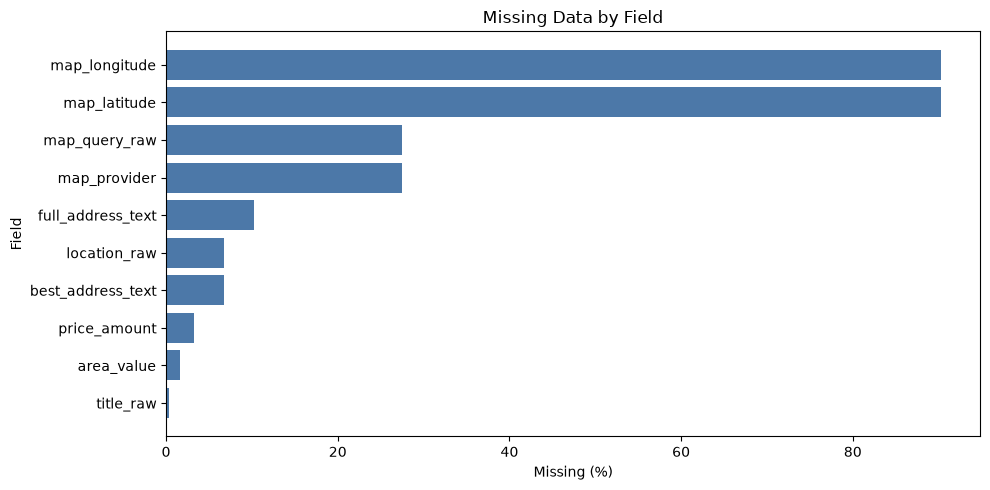

In [15]:
missing_flags = df.isna()
text_fields = df.select_dtypes(include=["object", "string"]).columns
missing_flags[text_fields] |= df[text_fields].apply(lambda column: column.astype("string").str.fullmatch(r"\s*", na=False))
missing_summary = pd.DataFrame({"Field": df.columns, "Available Rows": len(df) - missing_flags.sum().values, "Missing Rows": missing_flags.sum().values, "Missing (%)": (missing_flags.mean().values * 100).round(2)}).sort_values("Missing (%)", ascending=False)
display(missing_summary)
missing_plot = missing_summary[missing_summary["Missing Rows"] > 0].sort_values("Missing (%)")
plt.figure(figsize=(10, 5)); plt.barh(missing_plot["Field"], missing_plot["Missing (%)"], color="#4C78A8")
plt.title("Missing Data by Field"); plt.xlabel("Missing (%)"); plt.ylabel("Field"); plt.tight_layout(); plt.show()


## 03.2 Important-field Missingness

> **Purpose:** Focus completeness review on fields needed for downstream analysis.


In [16]:
important_fields = [field for field in ["title_raw", "price_amount", "area_value", "full_address_text", "location_raw", "best_address_text", "map_latitude", "map_longitude"] if field in df.columns]
missing_summary[missing_summary["Field"].isin(important_fields)]


,Field,Available Rows,Missing Rows,Missing (%)
12,map_longitude,12849,119587,90.3
11,map_latitude,12849,119587,90.3
7,full_address_text,118864,13572,10.25
14,best_address_text,123494,8942,6.75
8,location_raw,123494,8942,6.75
5,price_amount,128148,4288,3.24
6,area_value,130316,2120,1.6
3,title_raw,131947,489,0.37


## 03.3 Missingness by Source

> **Purpose:** Identify source-specific collection gaps in important fields.


,Data Source,title_raw,price_amount,area_value,full_address_text,location_raw,best_address_text,map_latitude,map_longitude
0,cafeland,0.0,0.05,0.02,0.0,0.0,0.0,69.28,69.28
1,chothuenha,0.0,0.00,100.00,0.0,0.0,0.0,100.00,100.00
2,chothuephongtro,0.0,11.30,0.05,0.04,0.0,0.0,100.00,100.00
3,mogi,0.0,0.00,0.03,0.0,0.0,0.0,0.67,0.67
4,muaban,0.0,0.12,100.00,54.41,0.0,0.0,100.00,100.00
5,nhatot,18.51,0.11,0.23,11.43,0.0,0.0,100.00,100.00
6,nhatrovn,0.0,0.00,11.05,2.07,0.0,0.0,100.00,100.00
7,phongtro123,0.0,0.31,0.05,17.3,12.52,12.52,100.00,100.00
8,tromoi,0.0,4.31,100.00,0.39,0.0,0.0,74.12,74.12


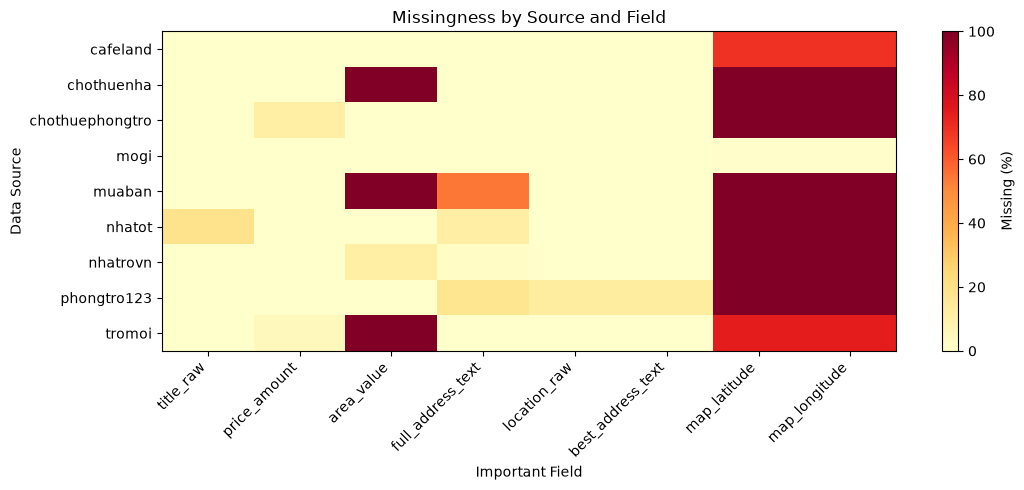

In [17]:
missingness_by_source = missing_flags.groupby(df["source_code"])[important_fields].mean().mul(100).round(2)
display(missingness_by_source.rename_axis("Data Source").reset_index())
plt.figure(figsize=(11, 5)); image = plt.imshow(missingness_by_source.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
plt.colorbar(image, label="Missing (%)"); plt.xticks(range(len(important_fields)), important_fields, rotation=45, ha="right"); plt.yticks(range(len(missingness_by_source)), missingness_by_source.index)
plt.title("Missingness by Source and Field"); plt.xlabel("Important Field"); plt.ylabel("Data Source"); plt.tight_layout(); plt.show()


## 03.4 Missing Patterns and Co-missingness

> **Purpose:** Measure whether important fields tend to be missing together.


,Missing Pattern,Affected Rows,Affected (%)
0,Price and Area Both Missing,21,0.02
1,Address Available but Coordinates Missing,110645,83.55
2,Coordinates Available but Address Missing,0,0.00
3,Address and Coordinates Missing,8942,6.75
4,Latitude and Longitude Both Missing,119587,90.30


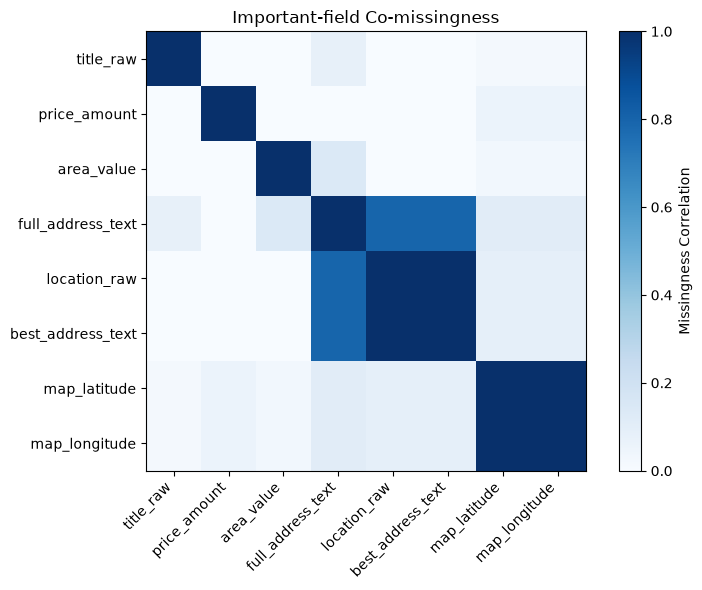

In [18]:
coordinates_missing = missing_flags["map_latitude"] | missing_flags["map_longitude"]
missing_patterns = {"Price and Area Both Missing": (missing_flags["price_amount"] & missing_flags["area_value"]).sum(), "Address Available but Coordinates Missing": (~missing_flags["best_address_text"] & coordinates_missing).sum(), "Coordinates Available but Address Missing": (missing_flags["best_address_text"] & ~coordinates_missing).sum(), "Address and Coordinates Missing": (missing_flags["best_address_text"] & coordinates_missing).sum(), "Latitude and Longitude Both Missing": (missing_flags["map_latitude"] & missing_flags["map_longitude"]).sum()}
missing_pattern_summary = pd.DataFrame({"Missing Pattern": list(missing_patterns), "Affected Rows": list(missing_patterns.values())}); missing_pattern_summary["Affected (%)"] = (missing_pattern_summary["Affected Rows"] / len(df) * 100).round(2)
display(missing_pattern_summary)
co_missingness = missing_flags[important_fields].astype(int).corr().fillna(0)
plt.figure(figsize=(8, 6)); image = plt.imshow(co_missingness.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=1); plt.colorbar(image, label="Missingness Correlation")
plt.xticks(range(len(important_fields)), important_fields, rotation=45, ha="right"); plt.yticks(range(len(important_fields)), important_fields); plt.title("Important-field Co-missingness"); plt.tight_layout(); plt.show()


# 04. Numeric Quality & Outlier Analysis

> **Purpose:** Distinguish invalid values from statistical outliers and suspicious extremes.


In [19]:
numeric_fields = [field for field in ["price_amount", "area_value", "active_days", "map_latitude", "map_longitude"] if field in df.columns]
numeric_data = df[numeric_fields].apply(pd.to_numeric, errors="coerce")


## 04.1 Price Distribution

> **Purpose:** Describe the raw price distribution without hiding extreme values.


,Metric,Value
0,Count,1.281480e+05
1,Missing,4.288000e+03
2,Minimum,1.000000e+03
3,P01,7.700000e+05
4,P05,1.300000e+06
5,P25,3.000000e+06
6,Median,4.000000e+06
7,P75,5.000000e+06
8,P95,1.000000e+07
9,P99,1.000000e+07


/tmp/ipykernel_9148/793194793.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(price_values, vert=False); axes[1].set_xscale("log"); axes[1].set(title="Raw Price Boxplot", xlabel="Price Amount (VND, log scale)"); plt.tight_layout(); plt.show()


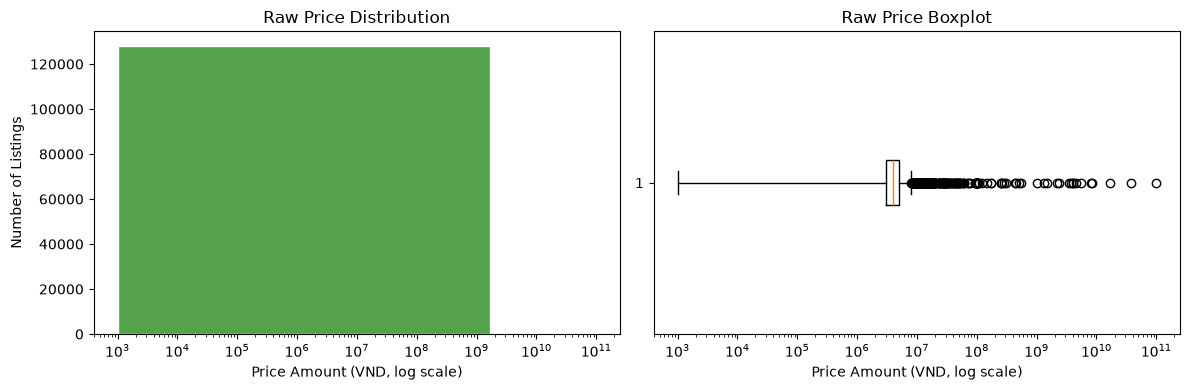

In [20]:
price_values = numeric_data["price_amount"].dropna(); price_quantiles = price_values.quantile([0, .01, .05, .25, .5, .75, .95, .99, 1])
price_summary = pd.DataFrame({"Metric": ["Count", "Missing", "Minimum", "P01", "P05", "P25", "Median", "P75", "P95", "P99", "Maximum"], "Value": [price_values.count(), numeric_data["price_amount"].isna().sum(), *price_quantiles.values]}); display(price_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); axes[0].hist(price_values, bins=60, color="#54A24B", edgecolor="white"); axes[0].set_xscale("log"); axes[0].set(title="Raw Price Distribution", xlabel="Price Amount (VND, log scale)", ylabel="Number of Listings")
axes[1].boxplot(price_values, vert=False); axes[1].set_xscale("log"); axes[1].set(title="Raw Price Boxplot", xlabel="Price Amount (VND, log scale)"); plt.tight_layout(); plt.show()


## 04.2 Price Outliers

> **Purpose:** Flag IQR and percentile extremes for review without classifying them as errors.


In [21]:
price_q1, price_q3 = price_values.quantile([.25, .75]); price_iqr = price_q3 - price_q1; price_lower_fence = price_q1 - 1.5 * price_iqr; price_upper_fence = price_q3 + 1.5 * price_iqr
price_outlier_mask = (numeric_data["price_amount"] < price_lower_fence) | (numeric_data["price_amount"] > price_upper_fence)
price_outlier_summary = pd.DataFrame({"Metric": ["Q1", "Q3", "IQR", "Lower Fence", "Upper Fence", "Rows Below Fence", "Rows Above Fence", "Percentage Flagged", "P99", "P99.5", "P99.9", "Maximum"], "Value": [price_q1, price_q3, price_iqr, price_lower_fence, price_upper_fence, (numeric_data["price_amount"] < price_lower_fence).sum(), (numeric_data["price_amount"] > price_upper_fence).sum(), price_outlier_mask.mean() * 100, *price_values.quantile([.99, .995, .999, 1]).values]})
price_sample_fields = [field for field in ["source_code", "source_listing_id", "price_amount", "area_value", "title_raw", "best_address_text"] if field in df.columns]
display(price_outlier_summary); df.nlargest(10, "price_amount")[price_sample_fields]


,Metric,Value
0,Q1,3.000000e+06
1,Q3,5.000000e+06
2,IQR,2.000000e+06
3,Lower Fence,0.000000e+00
4,Upper Fence,8.000000e+06
5,Rows Below Fence,0.000000e+00
6,Rows Above Fence,7.476000e+03
7,Percentage Flagged,5.644991e+00
8,P99,1.000000e+07
9,P99.5,1.000000e+07


,source_code,source_listing_id,price_amount,area_value,title_raw,best_address_text
36968,cafeland,2838449,9.900000e+10,224.5,Phòng trọ: Bán Building MT Hai Bà Trưng P6 Quậ...,Xuân Hòa TP. Hồ Chí Minh
104152,phongtro123,tinh-thanh/ho-chi-minh/phong-tro-cho-thue-co-g...,3.800000e+10,25.0,phòng trọ cho thuê có gác giá 3800k quận bình ...,NaN
36965,cafeland,2838454,1.700000e+10,100.0,Phòng trọ: Mặt tiền kinh doanh Phan Văn Trị Bì...,Bình Lợi Trung TP. Hồ Chí Minh
68213,phongtro123,627678,8.500000e+09,59.0,CHO THUÊ CĂN HỘ 2PN1WC VINHOMES QUẬN 9,"Đường Nguyễn Xiển, Phường Long Bình, Hồ Chí Minh"
37695,cafeland,2834881,8.000000e+09,60.0,Phòng trọ: Bán Nhà Mặt Tiền 3 Tầng - Kinh Doan...,Tăng Nhơn Phú TP. Hồ Chí Minh
102101,phongtro123,tinh-thanh/ho-chi-minh/phong-cho-thue-q3-khong...,5.500000e+09,40.0,PHÒNG CHO THUÊ Q3 KHÔNG GIỚI HẠN NGƯỜI Ở,NaN
72393,phongtro123,617842,4.500000e+09,30.0,Gác siêu thoáng - dương quảng hàm,"Phường An Nhơn, Hồ Chí Minh"
24992,mogi,22635973,4.000000e+09,20.0,Cho thuê phòng trọ FULL nội thất ngay ngã tư T...,"Hữu Nghị, Phường Bình Thọ, Quận Thủ Đức (TP. T..."
42279,nhatot,134814654,4.000000e+09,25.0,Mô tả chi tiết,"Hẻm 69, Đường Lê Lợi, Phường 4, Quận Gò Vấp, T..."
104097,phongtro123,tinh-thanh/ho-chi-minh/cho-thue-nha-tro%cc%a3-...,3.700000e+09,25.0,Cho thuê nhà trọ giá 3tr7 tại nguyễn thị...,NaN


## 04.3 Area Distribution

> **Purpose:** Describe the raw area distribution without hiding extreme values.


,Metric,Value
0,Count,130316.0
1,Missing,2120.0
2,Minimum,1.0
3,P01,9.0
4,P05,15.0
5,P25,22.0
6,Median,28.0
7,P75,35.0
8,P95,50.0
9,P99,135.0


/tmp/ipykernel_9148/1198257255.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(area_values, vert=False); axes[1].set_xscale("log"); axes[1].set(title="Raw Area Boxplot", xlabel="Area (m², log scale)"); plt.tight_layout(); plt.show()


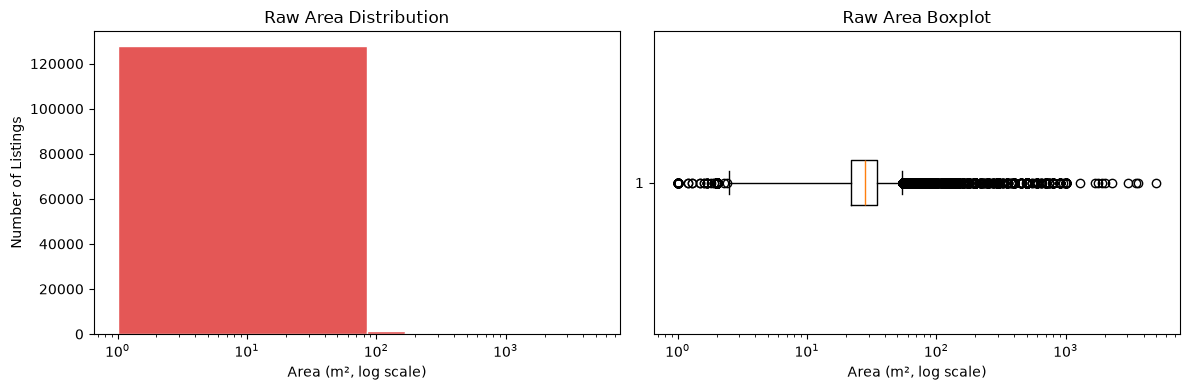

In [22]:
area_values = numeric_data["area_value"].dropna(); area_quantiles = area_values.quantile([0, .01, .05, .25, .5, .75, .95, .99, 1])
area_summary = pd.DataFrame({"Metric": ["Count", "Missing", "Minimum", "P01", "P05", "P25", "Median", "P75", "P95", "P99", "Maximum"], "Value": [area_values.count(), numeric_data["area_value"].isna().sum(), *area_quantiles.values]}); display(area_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); axes[0].hist(area_values, bins=60, color="#E45756", edgecolor="white"); axes[0].set_xscale("log"); axes[0].set(title="Raw Area Distribution", xlabel="Area (m², log scale)", ylabel="Number of Listings")
axes[1].boxplot(area_values, vert=False); axes[1].set_xscale("log"); axes[1].set(title="Raw Area Boxplot", xlabel="Area (m², log scale)"); plt.tight_layout(); plt.show()


## 04.4 Area Outliers

> **Purpose:** Flag IQR and percentile extremes for review without deleting them.


In [23]:
area_q1, area_q3 = area_values.quantile([.25, .75]); area_iqr = area_q3 - area_q1; area_lower_fence = area_q1 - 1.5 * area_iqr; area_upper_fence = area_q3 + 1.5 * area_iqr
area_outlier_mask = (numeric_data["area_value"] < area_lower_fence) | (numeric_data["area_value"] > area_upper_fence)
area_outlier_summary = pd.DataFrame({"Metric": ["Q1", "Q3", "IQR", "Lower Fence", "Upper Fence", "Rows Below Fence", "Rows Above Fence", "Percentage Flagged", "P99", "P99.5", "P99.9", "Maximum"], "Value": [area_q1, area_q3, area_iqr, area_lower_fence, area_upper_fence, (numeric_data["area_value"] < area_lower_fence).sum(), (numeric_data["area_value"] > area_upper_fence).sum(), area_outlier_mask.mean() * 100, *area_values.quantile([.99, .995, .999, 1]).values]})
area_sample_fields = [field for field in ["source_code", "source_listing_id", "area_value", "price_amount", "title_raw", "best_address_text"] if field in df.columns]
display(area_outlier_summary); pd.concat([df.nsmallest(5, "area_value"), df.nlargest(5, "area_value")])[area_sample_fields]


,Metric,Value
0,Q1,22.000000
1,Q3,35.000000
2,IQR,13.000000
3,Lower Fence,2.500000
4,Upper Fence,54.500000
5,Rows Below Fence,419.000000
6,Rows Above Fence,4873.000000
7,Percentage Flagged,3.995892
8,P99,135.000000
9,P99.5,300.000000


,source_code,source_listing_id,area_value,price_amount,title_raw,best_address_text
1093,phongtro123,713125,1.0,4700000.0,DUPLEX SẴN NỘI THẤT CƠ BẢN · THOÁNG MÁT — ĐƯỜN...,"Đường số 2, Phường An Hội Đông, Hồ Chí Minh"
5109,phongtro123,709356,1.0,1600000.0,"Cho Thuê Ktx Tại Số 9 Linh Xuân,Thủ Đức Chỉ Từ...","Đường số 9, Phường Linh Xuân, Hồ Chí Minh"
6529,phongtro123,707774,1.0,1500000.0,KTX XỊN GIỮA TRUNG TÂM MÀ GIÁ CHỈ TỪ 1M MẤY Si...,"60 Đường Nguyễn Tri Phương, Phường An Nhơn, Hồ..."
6719,phongtro123,621396,1.0,1300000.0,KTX NỮ PHÒNG 4 - 1.3Tr ngay 339 ĐỖ XUÂN HỢP gầ...,"92B Đường số 339, Phường Phước Long, Hồ Chí Minh"
10173,phongtro123,703652,1.0,1600000.0,KTX tư nhân Thủ Đức giá rẻ 1.6tr. Full nội thấ...,"59 Đường số 4, Phường Thủ Đức, Hồ Chí Minh"
22891,cafeland,3038967,5000.0,10000000.0,Phòng trọ: Cho thuê khu nhà nghỉ phòng trọ tại...,Thường Tân TP. Hồ Chí Minh
39646,cafeland,2791508,3614.0,7500000.0,Cho thuê phòng trọ: Chính Chủ Cho Thuê CHDV 2P...,Vườn Lài TP. Hồ Chí Minh
119976,phongtro123,692084,3500.0,800000.0,Phòng trọ cho thuê giá rẻ tại Nhơn Trạch,"Nhơn Trạch, Đồng Nai"
98649,phongtro123,tinh-thanh/ho-chi-minh/cho-thue-can-ho%cc%a3-m...,3025.0,2900000.0,"Cho thuê phòng tại 42/36/34E Hoàng Hoa Thám, p...","Đường Hoàng Hoa Thám, Phường Gia Định, Hồ Chí ..."
47617,mogi,22551923,2265.0,4000000.0,"Trọ CHÍNH CHỦ, gần CĐ Công Thương, Đỗ Xuân Hợp...","1 Đường số 8, Phường Tăng Nhơn Phú B, Quận 9 (..."


## 04.5 Other Numeric Fields

> **Purpose:** Check basic validity and ranges for temporal and coordinate fields.


In [24]:
other_numeric_fields = [field for field in ["active_days", "map_latitude", "map_longitude"] if field in numeric_data]
pd.DataFrame({"Field": other_numeric_fields, "Available Rows": numeric_data[other_numeric_fields].notna().sum().values, "Minimum": numeric_data[other_numeric_fields].min().values, "Median": numeric_data[other_numeric_fields].median().values, "Maximum": numeric_data[other_numeric_fields].max().values, "Negative Values": numeric_data[other_numeric_fields].lt(0).sum().values})


,Field,Available Rows,Minimum,Median,Maximum,Negative Values
0,active_days,132436,0.000000,5.000000,10.000000,0
1,map_latitude,12849,10.356375,10.798622,11.141580,0
2,map_longitude,12849,106.449198,106.670151,107.231177,0


## 04.6 Price × Area Consistency

> **Purpose:** Detect suspicious price–area combinations and extreme audit-only ratios.


,Value
count,1.260490e+05
mean,1.983225e+05
std,4.679903e+06
min,1.428571e+01
1%,1.000000e+04
5%,3.666667e+04
25%,1.133333e+05
50%,1.500000e+05
75%,1.923077e+05
95%,3.333333e+05


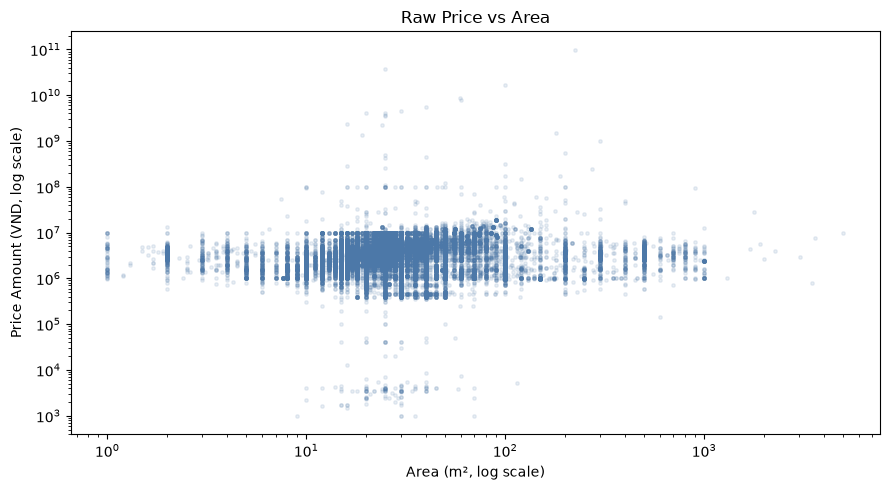

,source_code,source_listing_id,price_amount,area_value,title_raw,best_address_text,price_per_area
104152,phongtro123,tinh-thanh/ho-chi-minh/phong-tro-cho-thue-co-g...,3.800000e+10,25.0,phòng trọ cho thuê có gác giá 3800k quận bình ...,NaN,1.520000e+09
36968,cafeland,2838449,9.900000e+10,224.5,Phòng trọ: Bán Building MT Hai Bà Trưng P6 Quậ...,Xuân Hòa TP. Hồ Chí Minh,4.409800e+08
24992,mogi,22635973,4.000000e+09,20.0,Cho thuê phòng trọ FULL nội thất ngay ngã tư T...,"Hữu Nghị, Phường Bình Thọ, Quận Thủ Đức (TP. T...",2.000000e+08
36965,cafeland,2838454,1.700000e+10,100.0,Phòng trọ: Mặt tiền kinh doanh Phan Văn Trị Bì...,Bình Lợi Trung TP. Hồ Chí Minh,1.700000e+08
42279,nhatot,134814654,4.000000e+09,25.0,Mô tả chi tiết,"Hẻm 69, Đường Lê Lợi, Phường 4, Quận Gò Vấp, T...",1.600000e+08
72393,phongtro123,617842,4.500000e+09,30.0,Gác siêu thoáng - dương quảng hàm,"Phường An Nhơn, Hồ Chí Minh",1.500000e+08
102951,phongtro123,tinh-thanh/ho-chi-minh/phong-16m2-gia-2-400k-c...,2.400000e+09,16.0,Phòng 16m2 giá 2.400k cho 2-3 bạn nữ ở. Tới sa...,NaN,1.500000e+08
104097,phongtro123,tinh-thanh/ho-chi-minh/cho-thue-nha-tro%cc%a3-...,3.700000e+09,25.0,Cho thuê nhà trọ giá 3tr7 tại nguyễn thị...,NaN,1.480000e+08
68213,phongtro123,627678,8.500000e+09,59.0,CHO THUÊ CĂN HỘ 2PN1WC VINHOMES QUẬN 9,"Đường Nguyễn Xiển, Phường Long Bình, Hồ Chí Minh",1.440678e+08
104143,phongtro123,tinh-thanh/ho-chi-minh/phong-tien-nghi-cao-cap...,3.500000e+09,25.0,"Phòng tiện nghi cao cấp- giá bình dân, Được nấ...",NaN,1.400000e+08


In [25]:
price_area_mask = numeric_data["price_amount"].gt(0) & numeric_data["area_value"].gt(0)
price_area_audit = df.loc[price_area_mask, ["source_code", "source_listing_id", "price_amount", "area_value", "title_raw", "best_address_text"]].copy(); price_area_audit["price_per_area"] = pd.to_numeric(price_area_audit["price_amount"], errors="coerce") / pd.to_numeric(price_area_audit["area_value"], errors="coerce")
display(price_area_audit["price_per_area"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .995, .999]).to_frame("Value"))
plt.figure(figsize=(9, 5)); plt.scatter(price_area_audit["area_value"], price_area_audit["price_amount"], s=6, alpha=.12, color="#4C78A8"); plt.xscale("log"); plt.yscale("log")
plt.title("Raw Price vs Area"); plt.xlabel("Area (m², log scale)"); plt.ylabel("Price Amount (VND, log scale)"); plt.tight_layout(); plt.show()
price_area_audit.nlargest(10, "price_per_area")


# 05. Text Quality Analysis

> **Purpose:** Detect representation and length anomalies without modifying raw text.


## 05.1 Text Representation Issues

> **Purpose:** Measure whitespace, icon, control-character, and separator issues.


,Text Field,Quality Issue,Affected Rows
3,title_raw,Emoji or Icons,1767
15,location_raw,Emoji or Icons,165
27,best_address_text,Emoji or Icons,157
9,full_address_text,Emoji or Icons,155
17,location_raw,Repeated Unusual Separators,113
...,...,...,...
28,best_address_text,Invisible or Control Characters,6
14,location_raw,Repeated Internal Whitespace,4
8,full_address_text,Repeated Internal Whitespace,3
26,best_address_text,Repeated Internal Whitespace,3


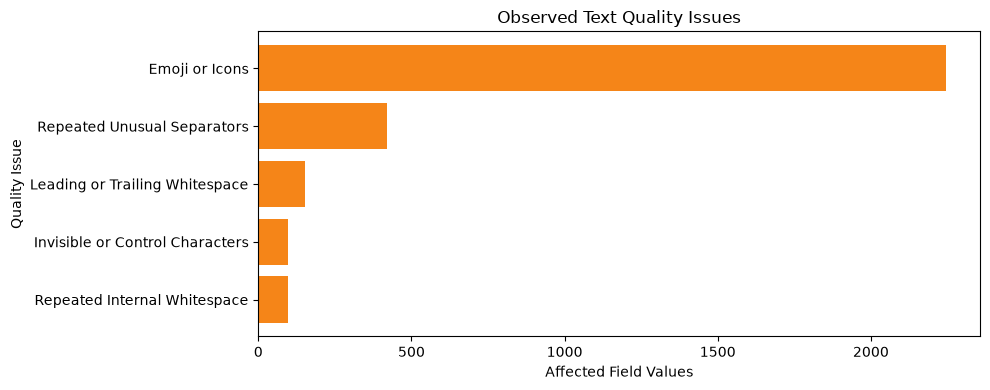

In [26]:
text_fields = [field for field in ["title_raw", "full_address_text", "location_raw", "map_query_raw", "best_address_text"] if field in df.columns]
text_checks = {"Empty or Whitespace Only": r"^\s*$", "Leading or Trailing Whitespace": r"^\s|\s$", "Repeated Internal Whitespace": r"\s{2,}", "Emoji or Icons": r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", "Invisible or Control Characters": r"[\u200B-\u200D\u2060\uFEFF\x00-\x08\x0B\x0C\x0E-\x1F\x7F]", "Repeated Unusual Separators": r"[|;_-]{2,}"}
text_quality = pd.DataFrame([{"Text Field": field, "Quality Issue": issue, "Affected Rows": df[field].astype("string").str.contains(pattern, regex=True, na=False).sum()} for field in text_fields for issue, pattern in text_checks.items()]); text_quality = text_quality[text_quality["Affected Rows"] > 0].sort_values("Affected Rows", ascending=False)
text_issue_rows = df[text_fields].apply(lambda column: column.astype("string").str.contains("|".join(text_checks.values()), regex=True, na=False)).any(axis=1); display(text_quality)
issue_totals = text_quality.groupby("Quality Issue")["Affected Rows"].sum().sort_values(); plt.figure(figsize=(10, 4)); plt.barh(issue_totals.index, issue_totals.values, color="#F58518")
plt.title("Observed Text Quality Issues"); plt.xlabel("Affected Field Values"); plt.ylabel("Quality Issue"); plt.tight_layout(); plt.show()


## 05.2 Text Length Analysis

> **Purpose:** Flag unusually short or long titles and addresses for review.


,Text Field,count,mean,std,min,1%,...,25%,50%,75%,95%,99%,max
0,title_raw,131947.0,63.614914,19.521028,1.0,14.0,...,50.0,64.0,79.0,96.0,105.0,172.0
1,best_address_text,123494.0,49.825473,27.917656,2.0,11.0,...,44.0,50.0,55.0,64.0,83.0,500.0


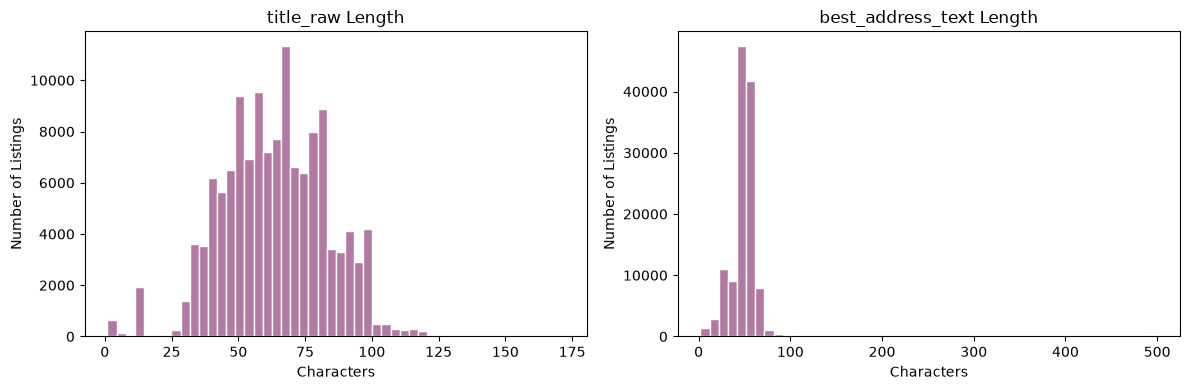

In [27]:
length_fields = [field for field in ["title_raw", "best_address_text"] if field in df.columns]; text_lengths = pd.DataFrame({field: df[field].astype("string").str.len() for field in length_fields})
display(text_lengths.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.reset_index(names="Text Field"))
fig, axes = plt.subplots(1, len(length_fields), figsize=(12, 4))
for axis, field in zip(np.atleast_1d(axes), length_fields): axis.hist(text_lengths[field].dropna(), bins=50, color="#B279A2", edgecolor="white"); axis.set(title=f"{field} Length", xlabel="Characters", ylabel="Number of Listings")
plt.tight_layout(); plt.show()


# 06. Address & Location Quality

> **Purpose:** Audit address coverage, format, administrative compatibility, and coordinates.


## 06.1 Address and Location Coverage

> **Purpose:** Compare raw, derived administrative, and coordinate coverage.


,Location Field,Coverage (%)
0,Full Address,89.752031
1,Best Address,93.248059
2,Street (Diagnostic Parser),72.052161
3,Ward (Diagnostic Parser),74.574889
4,District (Diagnostic Parser),65.943550
5,Province (Diagnostic Parser),9.558579
6,Complete Coordinate Pair,9.702045


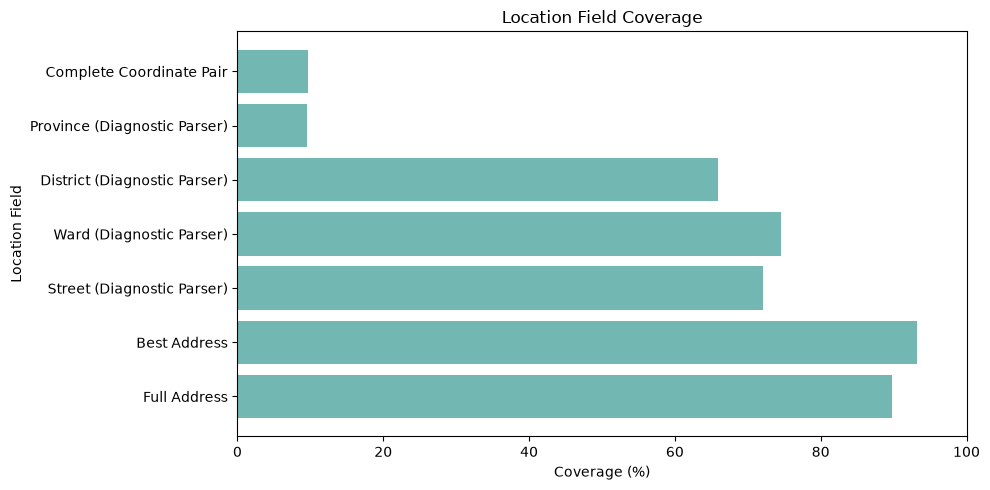

In [28]:
location_audit = apply_address_parsing(df[["rental_post_id", "source_code", "best_address_text"]].copy(), "best_address_text"); location_audit = apply_ward_mapping(location_audit, "ward_text_extracted", "district_text_extracted")
location_coverage_values = {"Full Address": (~missing_flags["full_address_text"]).mean() * 100, "Best Address": (~missing_flags["best_address_text"]).mean() * 100, "Street (Diagnostic Parser)": location_audit["street_text_extracted"].notna().mean() * 100, "Ward (Diagnostic Parser)": location_audit["ward_text_extracted"].notna().mean() * 100, "District (Diagnostic Parser)": location_audit["district_text_extracted"].notna().mean() * 100, "Province (Diagnostic Parser)": location_audit["province_text_extracted"].notna().mean() * 100, "Complete Coordinate Pair": ((~missing_flags["map_latitude"]) & (~missing_flags["map_longitude"])).mean() * 100}
location_coverage = pd.DataFrame({"Location Field": list(location_coverage_values), "Coverage (%)": list(location_coverage_values.values())}); display(location_coverage)
plt.figure(figsize=(10, 5)); plt.barh(location_coverage["Location Field"], location_coverage["Coverage (%)"], color="#72B7B2"); plt.title("Location Field Coverage"); plt.xlabel("Coverage (%)"); plt.ylabel("Location Field"); plt.xlim(0, 100); plt.tight_layout(); plt.show()


## 06.2 Address Length and Format Outliers

> **Purpose:** Flag unusually short and long address representations without treating them as errors.


,Metric,Value
0,Minimum,2.0
1,P01,11.0
2,P05,24.0
3,Q1,44.0
4,Median,50.0
5,Q3,55.0
6,P95,64.0
7,P99,83.0
8,Maximum,500.0
9,Lower Fence,27.5


/tmp/ipykernel_9148/3661139035.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  fig, axes = plt.subplots(1, 2, figsize=(12, 4)); axes[0].hist(address_lengths.dropna(), bins=60, color="#FF9DA6", edgecolor="white"); axes[0].set(title="Best Address Length Distribution", xlabel="Characters", ylabel="Number of Listings"); axes[1].boxplot(address_lengths.dropna(), vert=False); axes[1].set(title="Best Address Length Boxplot", xlabel="Characters"); plt.tight_layout(); plt.show()


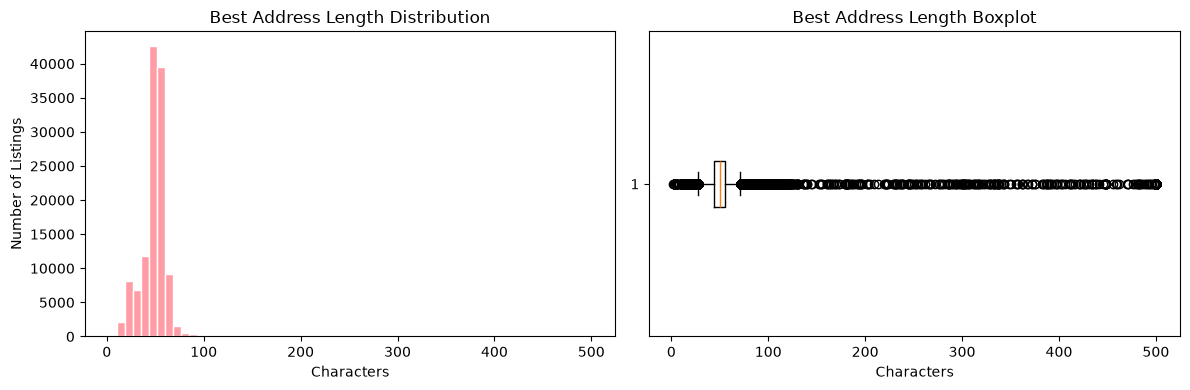

,source_code,source_listing_id,best_address_text
32455,nhatot,119371119,xã
2339,tromoi,phong-tro/can-ho-moi-xay-ngay-dai-hoc-cong-ngh...,386
2340,tromoi,phong-tro/can-ho-moi-xay-ngay-dai-hoc-cong-ngh...,386
8014,nhatot,134800748,null
8016,nhatot,134800725,null
20,mogi,22686508,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí ..."
87,mogi,22717439,"306 Gò Dầu, P Tân Quý, Q Tân Phú - Gần Tân Quý..."
93,mogi,22717435,"380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Th..."
97,mogi,22717440,"350 Huỳnh Tấn Phát, Q.7 - Xung quanh nhà có nh..."
103,mogi,21971822,Trung tâm quận Bình Thạnh số nhà 549 Đường Xô ...


In [29]:
address_lengths = df["best_address_text"].astype("string").str.len(); address_q1, address_q3 = address_lengths.quantile([.25, .75]); address_iqr = address_q3 - address_q1; address_lower_fence = address_q1 - 1.5 * address_iqr; address_upper_fence = address_q3 + 1.5 * address_iqr
address_length_summary = pd.DataFrame({"Metric": ["Minimum", "P01", "P05", "Q1", "Median", "Q3", "P95", "P99", "Maximum", "Lower Fence", "Upper Fence", "Rows Outside IQR Fences"], "Value": [*address_lengths.quantile([0, .01, .05, .25, .5, .75, .95, .99, 1]).values, address_lower_fence, address_upper_fence, ((address_lengths < address_lower_fence) | (address_lengths > address_upper_fence)).sum()]}); display(address_length_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); axes[0].hist(address_lengths.dropna(), bins=60, color="#FF9DA6", edgecolor="white"); axes[0].set(title="Best Address Length Distribution", xlabel="Characters", ylabel="Number of Listings"); axes[1].boxplot(address_lengths.dropna(), vert=False); axes[1].set(title="Best Address Length Boxplot", xlabel="Characters"); plt.tight_layout(); plt.show()
pd.concat([df.loc[address_lengths.nsmallest(5).index], df.loc[address_lengths.nlargest(5).index]])[["source_code", "source_listing_id", "best_address_text"]]


## 06.3 Address Structural Consistency

> **Purpose:** Measure mismatches between address evidence and diagnostic administrative components.


In [30]:
has_address = ~missing_flags["best_address_text"]
address_structure_issues = {"Address Available but Ward Missing": (has_address & location_audit["ward_text_extracted"].isna()).sum(), "Address Available but District Missing": (has_address & location_audit["district_text_extracted"].isna()).sum(), "Ward Available but Province Missing": (location_audit["ward_text_extracted"].notna() & location_audit["province_text_extracted"].isna()).sum(), "District Available but Ward Missing": (location_audit["district_text_extracted"].notna() & location_audit["ward_text_extracted"].isna()).sum(), "Address Missing but Administrative Component Parsed": (~has_address & location_audit[["ward_text_extracted", "district_text_extracted", "province_text_extracted"]].notna().any(axis=1)).sum()}
address_structure_summary = pd.DataFrame({"Quality Issue": list(address_structure_issues), "Affected Rows": list(address_structure_issues.values())}); address_structure_summary["Affected (%)"] = (address_structure_summary["Affected Rows"] / len(df) * 100).round(2); address_structure_summary


,Quality Issue,Affected Rows,Affected (%)
0,Address Available but Ward Missing,24730,18.67
1,Address Available but District Missing,36161,27.30
2,Ward Available but Province Missing,87425,66.01
3,District Available but Ward Missing,13942,10.53
4,Address Missing but Administrative Component P...,0,0.00


## 06.4 Administrative Unit Migration Audit

> **Purpose:** Measure compatibility with existing RoomBeacon post-merger mapping on temporary derived columns.

`WARD_MAPPING` is internal. Current parser tests expose unresolved edge cases, so these counts require human validation.


,Administrative Status,Number of Records,Percentage of Total (%)
0,UNCHANGED,37033,27.96
1,MAPPED,51559,38.93
2,AMBIGUOUS,4923,3.72
3,UNMAPPED,5249,3.96
4,MISSING,33672,25.43


,Data Source,Unresolved Records,Unresolved (%)
0,cafeland,10,0.10
1,chothuenha,10,11.90
2,chothuephongtro,5799,16.20
3,mogi,2164,22.12
4,muaban,306,18.88
5,nhatot,493,18.66
6,nhatrovn,287,33.03
7,phongtro123,1067,1.49
8,tromoi,36,14.12


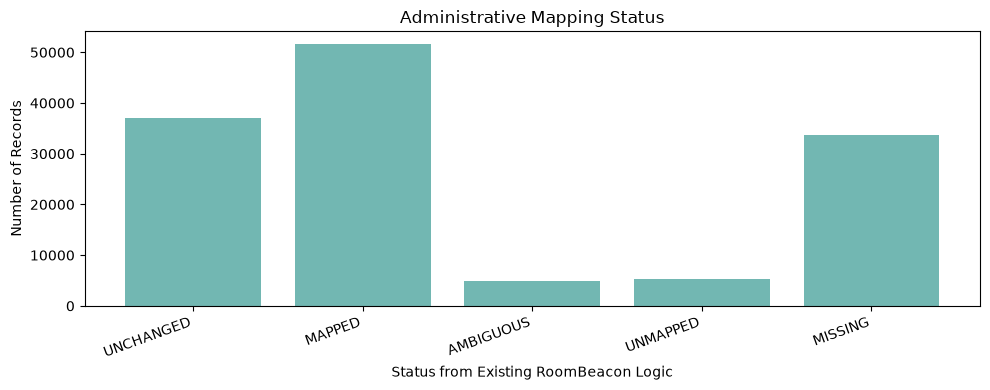

In [31]:
administrative_status = location_audit["ward_mapping_status"].value_counts(dropna=False).reindex(["UNCHANGED", "MAPPED", "AMBIGUOUS", "UNMAPPED", "MISSING"], fill_value=0).rename_axis("Administrative Status").reset_index(name="Number of Records"); administrative_status["Percentage of Total (%)"] = (administrative_status["Number of Records"] / len(df) * 100).round(2)
legacy_detected = location_audit["ward_mapping_status"].isin(["MAPPED", "AMBIGUOUS"]).sum(); successfully_mappable = location_audit["ward_mapping_status"].eq("MAPPED").sum(); unresolved_administrative = location_audit["ward_mapping_status"].isin(["AMBIGUOUS", "UNMAPPED"]).sum()
unresolved_by_source = location_audit.assign(Unresolved=location_audit["ward_mapping_status"].isin(["AMBIGUOUS", "UNMAPPED"])).groupby("source_code")["Unresolved"].agg(["sum", "mean"]).rename(columns={"sum": "Unresolved Records", "mean": "Unresolved (%)"}); unresolved_by_source["Unresolved (%)"] = (unresolved_by_source["Unresolved (%)"] * 100).round(2)
display(administrative_status); display(unresolved_by_source.reset_index(names="Data Source")); plt.figure(figsize=(10, 4)); plt.bar(administrative_status["Administrative Status"], administrative_status["Number of Records"], color="#72B7B2")
plt.title("Administrative Mapping Status"); plt.xlabel("Status from Existing RoomBeacon Logic"); plt.ylabel("Number of Records"); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()


## 06.5 Coordinate Quality

> **Purpose:** Measure coordinate completeness and known structural validity.


In [32]:
has_latitude = ~missing_flags["map_latitude"]; has_longitude = ~missing_flags["map_longitude"]; has_coordinates = has_latitude & has_longitude
coordinate_issues = {"Complete Coordinate Pair": has_coordinates.sum(), "Only Latitude Available": (has_latitude & ~has_longitude).sum(), "Only Longitude Available": (~has_latitude & has_longitude).sum(), "Invalid Latitude": (~df["map_latitude"].between(-90, 90) & has_latitude).sum(), "Invalid Longitude": (~df["map_longitude"].between(-180, 180) & has_longitude).sum(), "Address Available but Coordinates Missing": (has_address & ~has_coordinates).sum(), "Coordinates Available but Address Missing": (~has_address & has_coordinates).sum()}
pd.DataFrame({"Coordinate Check": list(coordinate_issues), "Affected Rows": list(coordinate_issues.values())})


,Coordinate Check,Affected Rows
0,Complete Coordinate Pair,12849
1,Only Latitude Available,0
2,Only Longitude Available,0
3,Invalid Latitude,0
4,Invalid Longitude,0
5,Address Available but Coordinates Missing,110645
6,Coordinates Available but Address Missing,0


# 07. Source-Level Data Quality

> **Purpose:** Compare important quality problems across sources without interpreting source size as market share.


,Data Source,Missing Title (%),Missing Price (%),Missing Area (%),Missing Address (%),Missing Ward (%),...,Missing Coordinates (%),Price Outlier (%),Area Outlier (%),Text Issue (%),Unresolved Admin (%),Post Detail
0,cafeland,0.0,0.05,0.02,0.0,65.88,...,69.28,6.48,6.61,0.03,0.10,9984
1,chothuenha,0.0,0.00,100.00,0.0,1.19,...,100.00,5.95,0.00,39.29,11.90,84
2,chothuephongtro,0.0,11.30,0.05,0.0,9.93,...,100.00,17.28,2.94,0.18,16.20,35796
3,mogi,0.0,0.00,0.03,0.0,2.28,...,0.67,1.02,4.79,16.87,22.12,9782
4,muaban,0.0,0.12,100.00,0.0,0.68,...,100.00,1.73,0.00,22.76,18.88,1621
5,nhatot,18.51,0.11,0.23,0.0,13.10,...,100.00,1.06,2.23,0.23,18.66,2642
6,nhatrovn,0.0,0.00,11.05,0.0,0.81,...,100.00,0.81,0.12,0.0,33.03,869
7,phongtro123,0.0,0.31,0.05,12.52,32.05,...,100.00,0.66,4.27,0.11,1.49,71403
8,tromoi,0.0,4.31,100.00,0.0,25.49,...,74.12,1.96,0.00,39.22,14.12,255


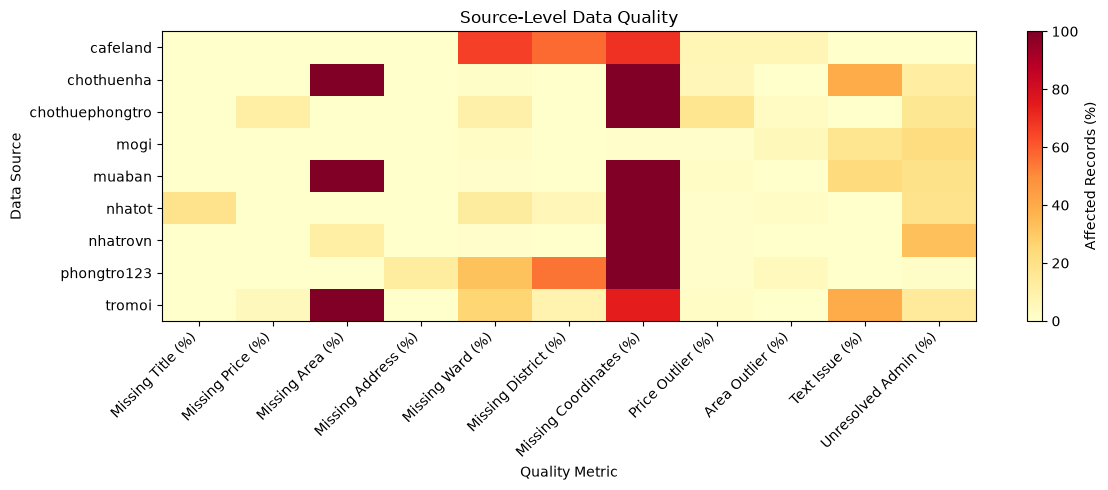

In [33]:
source_quality_flags = pd.DataFrame({"source_code": df["source_code"], "Missing Title (%)": missing_flags["title_raw"], "Missing Price (%)": missing_flags["price_amount"], "Missing Area (%)": missing_flags["area_value"], "Missing Address (%)": missing_flags["best_address_text"], "Missing Ward (%)": location_audit["ward_text_extracted"].isna(), "Missing District (%)": location_audit["district_text_extracted"].isna(), "Missing Coordinates (%)": ~has_coordinates, "Price Outlier (%)": price_outlier_mask.fillna(False), "Area Outlier (%)": area_outlier_mask.fillna(False), "Text Issue (%)": text_issue_rows, "Unresolved Admin (%)": location_audit["ward_mapping_status"].isin(["AMBIGUOUS", "UNMAPPED"])})
source_quality = source_quality_flags.groupby("source_code").mean().mul(100).round(2); source_counts = df.groupby("source_code").size().rename("Post Detail"); display(source_quality.join(source_counts).rename_axis("Data Source").reset_index())
plt.figure(figsize=(12, 5)); image = plt.imshow(source_quality.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=100); plt.colorbar(image, label="Affected Records (%)")
plt.xticks(range(len(source_quality.columns)), source_quality.columns, rotation=45, ha="right"); plt.yticks(range(len(source_quality)), source_quality.index); plt.title("Source-Level Data Quality"); plt.xlabel("Quality Metric"); plt.ylabel("Data Source"); plt.tight_layout(); plt.show()


# 08. Cross-variable Relationship Analysis

> **Purpose:** Inspect relationships, source effects and suspicious combinations in the current raw RoomBeacon dataset. Results are diagnostic—not market rankings or causal claims.

## 08.1 Price × Area Relationship

Positive raw values are analyzed without deleting or replacing records. Pearson measures linear association; Spearman measures monotonic association and is less sensitive to skew.

,Metric,Value
0,Listings,126049.000000
1,Pearson Correlation,0.010679
2,Spearman Correlation,0.304198


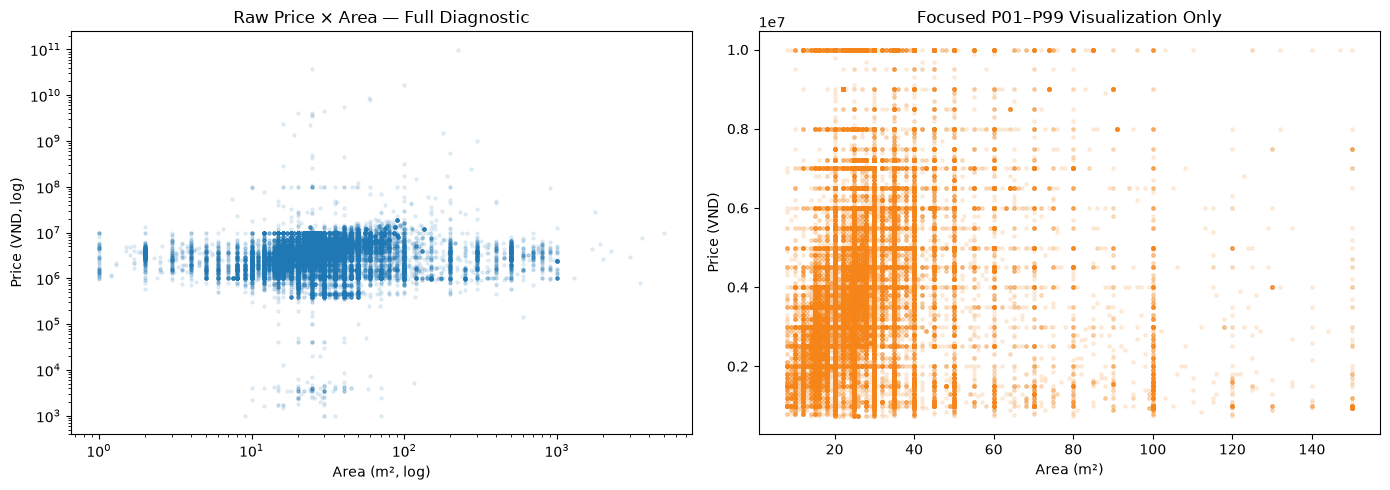

,Area Band (EDA only),Listings,Median Price,P25 Price,P75 Price
0,Under 15m²,4776,2200000.0,1600000.0,3000000.0
1,15–25m²,30848,3200000.0,2500000.0,4100000.0
2,25–40m²,73288,4400000.0,3300000.0,5500000.0
3,40–60m²,12806,5000000.0,3500000.0,6000000.0
4,Over 60m²,4331,3700000.0,1600000.0,6000000.0


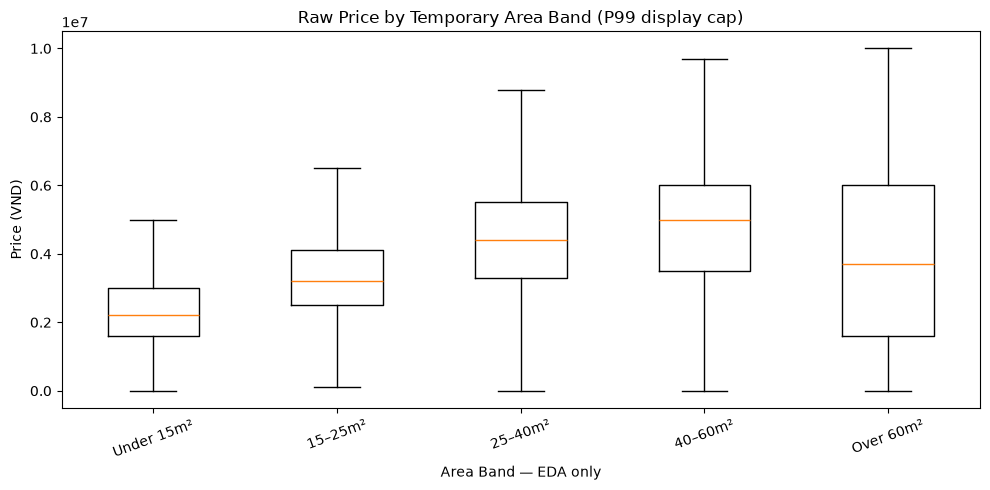

In [34]:
MIN_LOCATION_SAMPLE = 50
MIN_LOCATION_SOURCE_SAMPLE = 30
relationship_audit = df[["rental_post_id", "source_code", "source_listing_id", "title_raw", "price_amount", "area_value", "best_address_text", "map_latitude", "map_longitude"]].copy()
relationship_audit = relationship_audit.join(location_audit[["parse_status", "ward_text_extracted", "district_text_extracted", "ward_current", "ward_mapping_status"]])
relationship_audit["Price"] = pd.to_numeric(relationship_audit["price_amount"], errors="coerce")
relationship_audit["Area"] = pd.to_numeric(relationship_audit["area_value"], errors="coerce")
relationship_audit["Price Outlier"] = price_outlier_mask.fillna(False)
relationship_audit["Area Outlier"] = area_outlier_mask.fillna(False)
relationship_audit["Price per Area"] = relationship_audit["Price"].div(relationship_audit["Area"]).where(relationship_audit["Price"].gt(0) & relationship_audit["Area"].gt(0))
positive_pair = relationship_audit[relationship_audit["Price"].gt(0) & relationship_audit["Area"].gt(0)].copy()
relationship_correlation = pd.DataFrame({"Metric": ["Listings", "Pearson Correlation", "Spearman Correlation"], "Value": [len(positive_pair), positive_pair["Price"].corr(positive_pair["Area"], method="pearson"), positive_pair["Price"].corr(positive_pair["Area"], method="spearman")]})
display(relationship_correlation)
area_limits = positive_pair["Area"].quantile([.01, .99]); price_limits = positive_pair["Price"].quantile([.01, .99])
focused_pair = positive_pair[positive_pair["Area"].between(*area_limits) & positive_pair["Price"].between(*price_limits)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(positive_pair["Area"], positive_pair["Price"], s=5, alpha=.1); axes[0].set(xscale="log", yscale="log", title="Raw Price × Area — Full Diagnostic", xlabel="Area (m², log)", ylabel="Price (VND, log)")
axes[1].scatter(focused_pair["Area"], focused_pair["Price"], s=6, alpha=.12, color="#F58518"); axes[1].set(title="Focused P01–P99 Visualization Only", xlabel="Area (m²)", ylabel="Price (VND)"); plt.tight_layout(); plt.show()
area_edges = [0, 15, 25, 40, 60, np.inf]; area_labels = ["Under 15m²", "15–25m²", "25–40m²", "40–60m²", "Over 60m²"]
positive_pair["Area Band (EDA only)"] = pd.cut(positive_pair["Area"], area_edges, labels=area_labels, right=False)
area_band_price = positive_pair.groupby("Area Band (EDA only)", observed=True)["Price"].agg(Listings="size", **{"Median Price": "median", "P25 Price": lambda x: x.quantile(.25), "P75 Price": lambda x: x.quantile(.75)}).reset_index(); display(area_band_price)
plt.figure(figsize=(10, 5)); plt.boxplot([positive_pair.loc[positive_pair["Area Band (EDA only)"].eq(x), "Price"].clip(upper=price_limits.iloc[1]) for x in area_labels], tick_labels=area_labels, showfliers=False); plt.title("Raw Price by Temporary Area Band (P99 display cap)"); plt.xlabel("Area Band — EDA only"); plt.ylabel("Price (VND)"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 08.2 Location × Price

Only resolved current wards with at least `MIN_LOCATION_SAMPLE = 50` valid observations are compared. Sample sizes are displayed.

,Current Ward,Listings,Valid Price Records,Median Price,P25 Price,P75 Price,P95 Price,Price Outlier (%)
0,Phường Tân Hưng,8891,8545,5000000.0,4000000.0,6500000.0,10000000.0,7.254527
1,Phường Tân Thuận,5411,5247,4500000.0,3600000.0,6500000.0,10000000.0,9.184994
2,Phường Tân Sơn Nhất,3859,3601,4500000.0,3500000.0,5500000.0,10000000.0,8.084996
3,Phường An Hội Tây,3330,3275,3600000.0,3000000.0,4500000.0,7000000.0,3.363363
4,Phường An Nhơn,3014,2932,3900000.0,3000000.0,4500000.0,8000000.0,4.611812
...,...,...,...,...,...,...,...,...
15,Phường Hạnh Thông,1501,1456,3500000.0,2500000.0,4500000.0,8000000.0,4.663558
16,Phường Nhiêu Lộc,1496,1454,4500000.0,3500000.0,5500000.0,7000000.0,2.272727
17,Phường Tăng Nhơn Phú,1473,1447,3500000.0,2500000.0,4000000.0,6500000.0,1.629328
18,Phường Đức Nhuận,1354,1320,4500000.0,3200000.0,5500000.0,7900000.0,4.283604


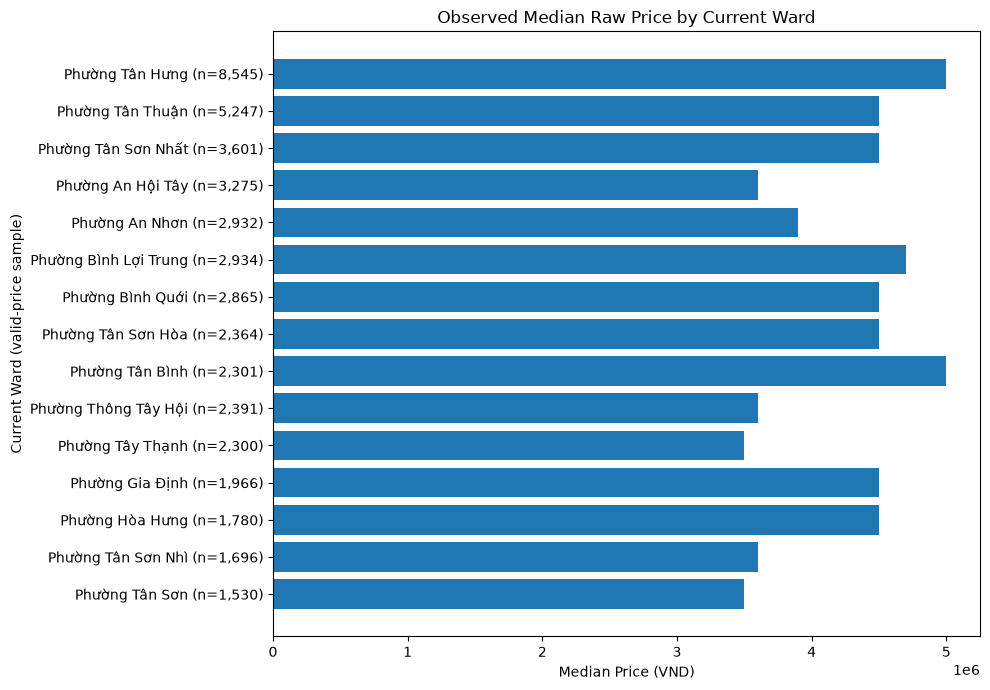

In [35]:
ward_base = relationship_audit.dropna(subset=["ward_current"]).copy()
location_price = ward_base.groupby("ward_current").agg(Listings=("rental_post_id", "size"), **{"Valid Price Records": ("Price", "count"), "Median Price": ("Price", "median"), "P25 Price": ("Price", lambda x: x.quantile(.25)), "P75 Price": ("Price", lambda x: x.quantile(.75)), "P95 Price": ("Price", lambda x: x.quantile(.95)), "Price Outlier (%)": ("Price Outlier", lambda x: x.mean() * 100)}).query("`Valid Price Records` >= @MIN_LOCATION_SAMPLE").sort_values("Listings", ascending=False)
display(location_price.reset_index(names="Current Ward").head(20)); plot_data = location_price.head(15)
plt.figure(figsize=(10, 7)); labels = [f"{w} (n={int(r['Valid Price Records']):,})" for w, r in plot_data.iterrows()]; plt.barh(labels[::-1], plot_data["Median Price"].iloc[::-1]); plt.title("Observed Median Raw Price by Current Ward"); plt.xlabel("Median Price (VND)"); plt.ylabel("Current Ward (valid-price sample)"); plt.tight_layout(); plt.show()

## 08.3 Location × Area

,Current Ward,Listings,Valid Area Records,Median Area,P25 Area,P75 Area,P95 Area,Area Outlier (%)
0,Phường Tân Hưng,8891,8849,32.0,30.0,37.0,50.0,3.756608
1,Phường Tân Thuận,5411,5365,30.0,28.0,35.0,50.0,3.123267
2,Phường Tân Sơn Nhất,3859,3826,30.0,25.0,35.0,50.0,3.627883
3,Phường An Hội Tây,3330,3277,25.0,20.0,30.0,40.0,2.402402
4,Phường An Nhơn,3014,2928,25.0,22.0,30.0,50.0,3.749171
...,...,...,...,...,...,...,...,...
15,Phường Hạnh Thông,1501,1480,25.0,20.0,30.0,70.0,6.195869
16,Phường Nhiêu Lộc,1496,1475,25.0,20.0,30.0,45.0,3.074866
17,Phường Tăng Nhơn Phú,1473,1460,26.0,22.0,30.0,50.0,4.887984
18,Phường Đức Nhuận,1354,1329,28.0,21.0,35.0,100.0,11.299852


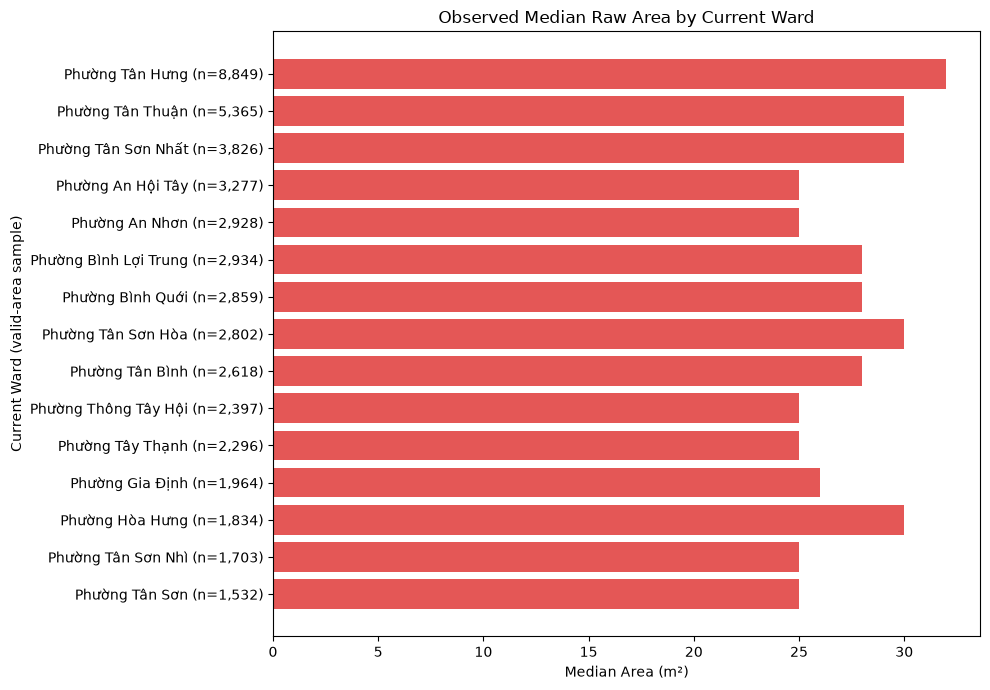

In [36]:
location_area = ward_base.groupby("ward_current").agg(Listings=("rental_post_id", "size"), **{"Valid Area Records": ("Area", "count"), "Median Area": ("Area", "median"), "P25 Area": ("Area", lambda x: x.quantile(.25)), "P75 Area": ("Area", lambda x: x.quantile(.75)), "P95 Area": ("Area", lambda x: x.quantile(.95)), "Area Outlier (%)": ("Area Outlier", lambda x: x.mean() * 100)}).query("`Valid Area Records` >= @MIN_LOCATION_SAMPLE").sort_values("Listings", ascending=False)
display(location_area.reset_index(names="Current Ward").head(20)); plot_data = location_area.head(15)
plt.figure(figsize=(10, 7)); labels = [f"{w} (n={int(r['Valid Area Records']):,})" for w, r in plot_data.iterrows()]; plt.barh(labels[::-1], plot_data["Median Area"].iloc[::-1], color="#E45756"); plt.title("Observed Median Raw Area by Current Ward"); plt.xlabel("Median Area (m²)"); plt.ylabel("Current Ward (valid-area sample)"); plt.tight_layout(); plt.show()

## 08.4 Location × Price per Area

Price per area is temporary diagnostic evidence calculated only for positive raw price and area pairs.

,Current Ward,Listings,Valid Price-per-Area Records,Median Price per Area,P25,P75,P95
0,Phường Tân Hưng,8891,8503,155555.555556,120000.000000,200000.000000,312500.000000
1,Phường Tân Thuận,5411,5201,150000.000000,120000.000000,200000.000000,333333.333333
2,Phường Tân Sơn Nhất,3859,3568,153333.333333,125000.000000,192000.000000,333333.333333
3,Phường An Hội Tây,3330,3222,144000.000000,120000.000000,180000.000000,300000.000000
4,Phường An Nhơn,3014,2846,150000.000000,120000.000000,184000.000000,333333.333333
...,...,...,...,...,...,...,...
15,Phường Hạnh Thông,1501,1435,150000.000000,110555.555556,188000.000000,400000.000000
16,Phường Nhiêu Lộc,1496,1433,175000.000000,140000.000000,214285.714286,300000.000000
17,Phường Tăng Nhơn Phú,1473,1434,126666.666667,100000.000000,159217.171717,278555.555556
18,Phường Đức Nhuận,1354,1295,166666.666667,129444.444444,200000.000000,313750.000000


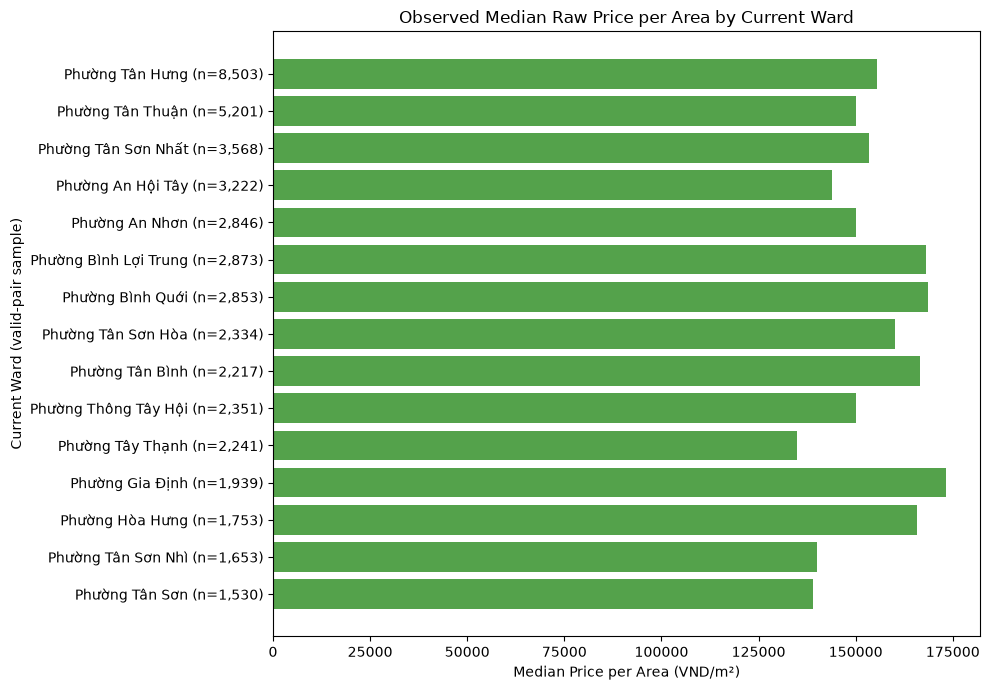

In [37]:
location_price_area = ward_base.groupby("ward_current").agg(Listings=("rental_post_id", "size"), **{"Valid Price-per-Area Records": ("Price per Area", "count"), "Median Price per Area": ("Price per Area", "median"), "P25": ("Price per Area", lambda x: x.quantile(.25)), "P75": ("Price per Area", lambda x: x.quantile(.75)), "P95": ("Price per Area", lambda x: x.quantile(.95))}).query("`Valid Price-per-Area Records` >= @MIN_LOCATION_SAMPLE").sort_values("Listings", ascending=False)
display(location_price_area.reset_index(names="Current Ward").head(20)); plot_data = location_price_area.head(15)
plt.figure(figsize=(10, 7)); labels = [f"{w} (n={int(r['Valid Price-per-Area Records']):,})" for w, r in plot_data.iterrows()]; plt.barh(labels[::-1], plot_data["Median Price per Area"].iloc[::-1], color="#54A24B"); plt.title("Observed Median Raw Price per Area by Current Ward"); plt.xlabel("Median Price per Area (VND/m²)"); plt.ylabel("Current Ward (valid-pair sample)"); plt.tight_layout(); plt.show()

## 08.5 Source × Price

Source differences describe crawler representation and parsing behavior—not market activity or causation.

,Data Source,Listings,Valid Price Records,Median Price,P25 Price,P75 Price,P95 Price,Price Outlier (%),Suspicious Low Price (%)
0,phongtro123,71403,71181,3500000.0,2700000.0,4500000.0,6000000.0,0.661037,1.582567
1,chothuephongtro,35796,31751,6000000.0,4500000.0,7000000.0,10000000.0,17.275673,0.002794
2,cafeland,9984,9979,4200000.0,3400000.0,5400000.0,9000000.0,6.480369,0.070112
3,mogi,9782,9782,3000000.0,2000000.0,4000000.0,6000000.0,1.022286,0.132897
4,nhatot,2642,2639,3600000.0,2800000.0,4500000.0,6500000.0,1.059803,2.157456
5,muaban,1621,1619,4000000.0,3300000.0,4900000.0,6800000.0,1.727329,0.000000
6,nhatrovn,869,869,4500000.0,3500000.0,5510000.0,7500000.0,0.805524,0.000000
7,tromoi,255,244,2500000.0,1700000.0,4500000.0,7000000.0,1.960784,0.392157
8,chothuenha,84,84,4000000.0,3200000.0,5725000.0,8850000.0,5.952381,0.000000


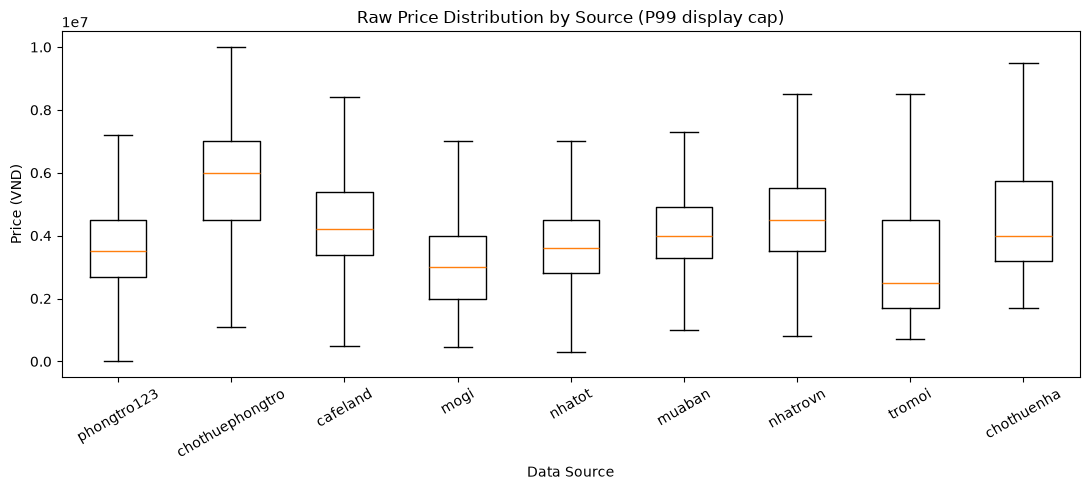

In [38]:
price_floor = positive_pair["Price"].quantile(.01)
source_price = relationship_audit.groupby("source_code").agg(Listings=("rental_post_id", "size"), **{"Valid Price Records": ("Price", "count"), "Median Price": ("Price", "median"), "P25 Price": ("Price", lambda x: x.quantile(.25)), "P75 Price": ("Price", lambda x: x.quantile(.75)), "P95 Price": ("Price", lambda x: x.quantile(.95)), "Price Outlier (%)": ("Price Outlier", lambda x: x.mean() * 100), "Suspicious Low Price (%)": ("Price", lambda x: x.lt(price_floor).mean() * 100)}).query("`Valid Price Records` >= @MIN_LOCATION_SAMPLE").sort_values("Valid Price Records", ascending=False); display(source_price.reset_index(names="Data Source"))
source_price_values = [relationship_audit.loc[relationship_audit["source_code"].eq(x), "Price"].dropna().clip(upper=price_limits.iloc[1]) for x in source_price.index]
plt.figure(figsize=(11, 5)); plt.boxplot(source_price_values, tick_labels=source_price.index, showfliers=False); plt.title("Raw Price Distribution by Source (P99 display cap)"); plt.xlabel("Data Source"); plt.ylabel("Price (VND)"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 08.6 Source × Area

,Data Source,Listings,Valid Area Records,Median Area,P25 Area,P75 Area,P95 Area,Area Outlier (%)
0,phongtro123,71403,71367,25.0,20.0,30.0,50.0,4.274330
1,chothuephongtro,35796,35779,30.0,25.0,35.0,50.0,2.936082
2,cafeland,9984,9982,28.0,22.0,35.0,64.0,6.610577
3,mogi,9782,9779,30.0,25.0,33.0,50.0,4.794521
4,nhatot,2642,2636,25.0,20.0,30.0,45.0,2.233157
5,nhatrovn,869,773,20.0,20.0,20.0,30.0,0.115075


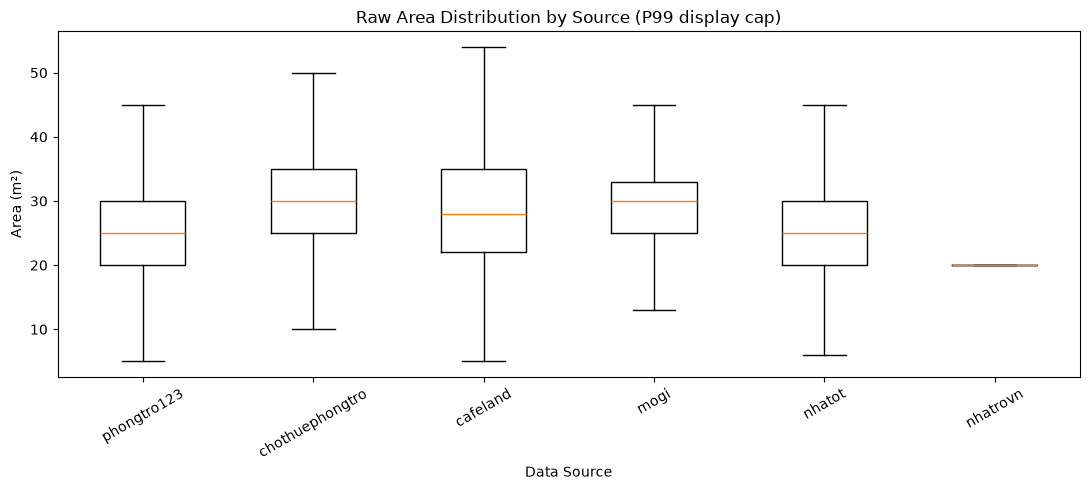

In [39]:
source_area = relationship_audit.groupby("source_code").agg(Listings=("rental_post_id", "size"), **{"Valid Area Records": ("Area", "count"), "Median Area": ("Area", "median"), "P25 Area": ("Area", lambda x: x.quantile(.25)), "P75 Area": ("Area", lambda x: x.quantile(.75)), "P95 Area": ("Area", lambda x: x.quantile(.95)), "Area Outlier (%)": ("Area Outlier", lambda x: x.mean() * 100)}).query("`Valid Area Records` >= @MIN_LOCATION_SAMPLE").sort_values("Valid Area Records", ascending=False); display(source_area.reset_index(names="Data Source"))
area_display_cap = relationship_audit["Area"].quantile(.99); source_area_values = [relationship_audit.loc[relationship_audit["source_code"].eq(x), "Area"].dropna().clip(upper=area_display_cap) for x in source_area.index]
plt.figure(figsize=(11, 5)); plt.boxplot(source_area_values, tick_labels=source_area.index, showfliers=False); plt.title("Raw Area Distribution by Source (P99 display cap)"); plt.xlabel("Data Source"); plt.ylabel("Area (m²)"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 08.7 Source × Location

,Current Ward,Listings,Number of Sources,Largest Source Share (%)
0,Phường Tân Hưng,8891,9,75.098414
1,Phường Tân Thuận,5411,8,70.596932
2,Phường Tân Sơn Nhất,3859,7,54.159109
3,Phường An Hội Tây,3330,9,61.561562
4,Phường An Nhơn,3014,9,55.109489
...,...,...,...,...
15,Phường Hạnh Thông,1501,7,75.083278
16,Phường Nhiêu Lộc,1496,8,68.582888
17,Phường Tăng Nhơn Phú,1473,8,72.505092
18,Phường Đức Nhuận,1354,6,69.350074


,Data Source,Resolved Ward Records,Unique Current Wards,Largest Ward Share (%)
0,phongtro123,47449,77,5.220342
1,chothuephongtro,26442,75,25.251494
2,mogi,7395,75,6.409736
3,cafeland,3397,18,17.574330
4,nhatot,1803,66,7.099279
5,muaban,1304,66,6.058282
6,nhatrovn,575,57,7.652174
7,tromoi,154,45,8.441558
8,chothuenha,73,40,6.849315


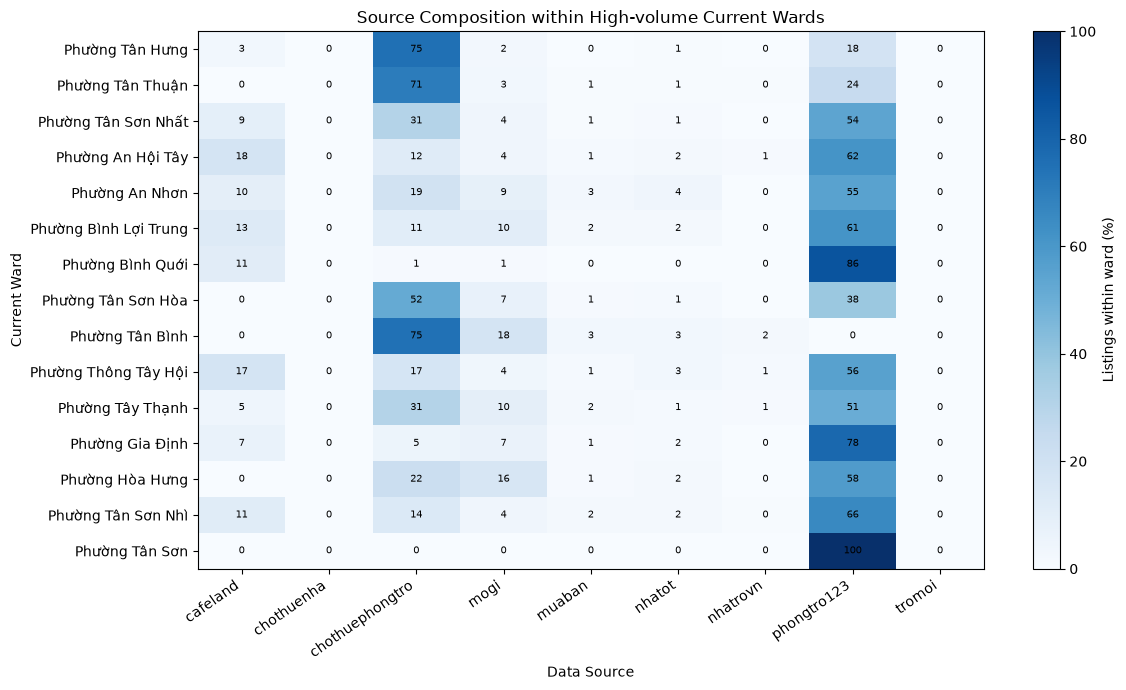

In [40]:
ward_source_counts = ward_base.groupby(["ward_current", "source_code"]).size().rename("Listings").reset_index()
ward_source_summary = ward_source_counts.groupby("ward_current").agg(Listings=("Listings", "sum"), **{"Number of Sources": ("source_code", "nunique"), "Largest Source Share (%)": ("Listings", lambda x: x.max() / x.sum() * 100)}).query("Listings >= @MIN_LOCATION_SAMPLE").sort_values("Listings", ascending=False)
source_ward_summary = ward_source_counts.groupby("source_code").agg(**{"Resolved Ward Records": ("Listings", "sum"), "Unique Current Wards": ("ward_current", "nunique"), "Largest Ward Share (%)": ("Listings", lambda x: x.max() / x.sum() * 100)}).sort_values("Resolved Ward Records", ascending=False)
display(ward_source_summary.reset_index(names="Current Ward").head(20)); display(source_ward_summary.reset_index(names="Data Source"))
heatmap_wards = ward_source_summary.head(15).index
ward_source_heatmap = ward_source_counts[ward_source_counts["ward_current"].isin(heatmap_wards)].pivot(index="ward_current", columns="source_code", values="Listings").fillna(0).reindex(heatmap_wards); ward_source_heatmap = ward_source_heatmap.div(ward_source_heatmap.sum(axis=1), axis=0).mul(100)
fig, ax = plt.subplots(figsize=(12, 7)); image = ax.imshow(ward_source_heatmap, aspect="auto", cmap="Blues", vmin=0, vmax=100); plt.colorbar(image, ax=ax, label="Listings within ward (%)"); ax.set_xticks(range(len(ward_source_heatmap.columns)), ward_source_heatmap.columns, rotation=35, ha="right"); ax.set_yticks(range(len(ward_source_heatmap)), ward_source_heatmap.index)
for r in range(len(ward_source_heatmap)):
    for c in range(len(ward_source_heatmap.columns)): ax.text(c, r, f"{ward_source_heatmap.iat[r, c]:.0f}", ha="center", va="center", fontsize=7)
ax.set(title="Source Composition within High-volume Current Wards", xlabel="Data Source", ylabel="Current Ward"); plt.tight_layout(); plt.show()

## 08.8 Source × Location × Price

Groups below `MIN_LOCATION_SOURCE_SAMPLE = 30` remain blank; zero is never imputed.

,ward_current,source_code,Listings,Valid Price Records,Median Price,Median Area
181,Phường Tân Hưng,chothuephongtro,6677,6334,5000000.0,35.0
204,Phường Tân Thuận,chothuephongtro,3820,3662,5000000.0,35.0
46,Phường Bình Quới,phongtro123,2477,2473,4500000.0,28.0
203,Phường Tân Sơn Nhất,phongtro123,2090,2088,4000000.0,26.0
5,Phường An Hội Tây,phongtro123,2050,2047,3400000.0,25.0
...,...,...,...,...,...,...
75,Phường Chánh Hưng,phongtro123,928,928,3500000.0,25.0
236,Phường Đông Hưng Thuận,phongtro123,905,905,3000000.0,25.0
104,Phường Hiệp Bình,phongtro123,865,864,3200000.0,25.0
83,Phường Cát Lái,phongtro123,834,834,4000000.0,29.0


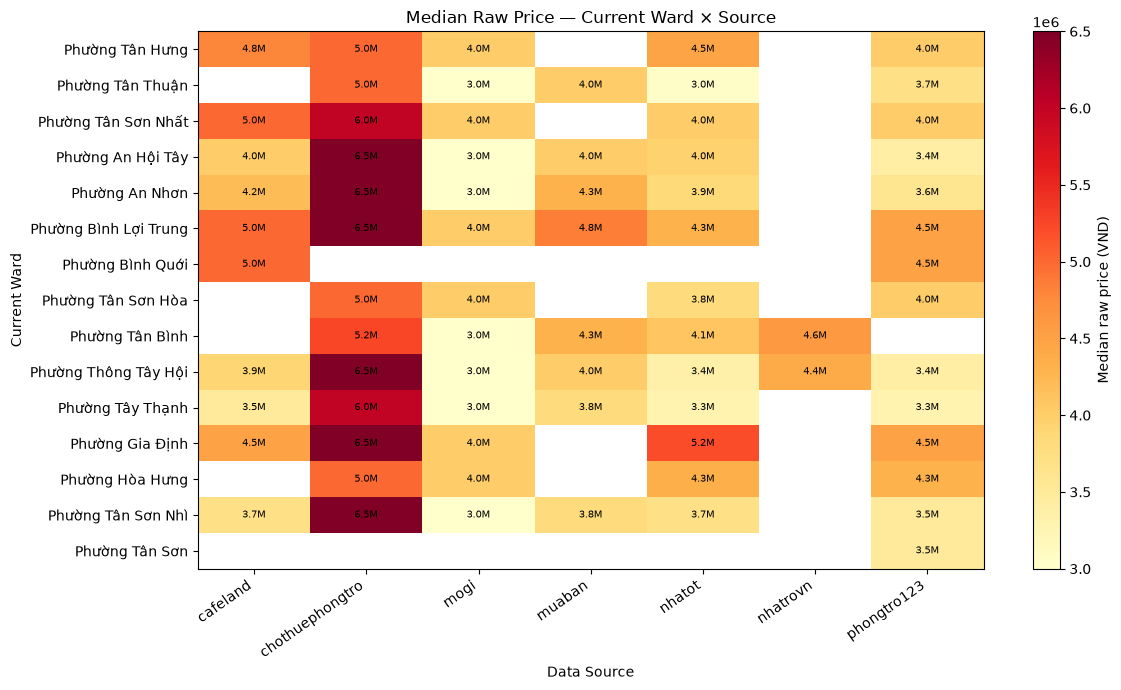

In [41]:
ward_source_price = ward_base.groupby(["ward_current", "source_code"]).agg(Listings=("rental_post_id", "size"), **{"Valid Price Records": ("Price", "count"), "Median Price": ("Price", "median"), "Median Area": ("Area", "median")}).query("`Valid Price Records` >= @MIN_LOCATION_SOURCE_SAMPLE").reset_index(); display(ward_source_price.sort_values("Listings", ascending=False).head(30))
price_heatmap = ward_source_price[ward_source_price["ward_current"].isin(heatmap_wards)].pivot(index="ward_current", columns="source_code", values="Median Price").reindex(heatmap_wards)
fig, ax = plt.subplots(figsize=(12, 7)); image = ax.imshow(price_heatmap, aspect="auto", cmap="YlOrRd"); plt.colorbar(image, ax=ax, label="Median raw price (VND)"); ax.set_xticks(range(len(price_heatmap.columns)), price_heatmap.columns, rotation=35, ha="right"); ax.set_yticks(range(len(price_heatmap)), price_heatmap.index)
for r in range(len(price_heatmap)):
    for c in range(len(price_heatmap.columns)):
        value = price_heatmap.iat[r, c]
        if pd.notna(value): ax.text(c, r, f"{value/1_000_000:.1f}M", ha="center", va="center", fontsize=7)
ax.set(title="Median Raw Price — Current Ward × Source", xlabel="Data Source", ylabel="Current Ward"); plt.tight_layout(); plt.show()

## 08.9 Address Resolution × Critical Fields

In [42]:
address_available = relationship_audit["best_address_text"].astype("string").str.strip().replace("", pd.NA).notna()
location_state = pd.Series("Ward Unresolved", index=df.index, dtype="string"); location_state.loc[relationship_audit["ward_current"].notna()] = "Current Ward Resolved"; location_state.loc[relationship_audit["parse_status"].isin(["UNRECOGNIZED_FORMAT", "MISSING"])] = "Parser Failure"; location_state.loc[~address_available] = "Address Missing"
address_resolution_critical = relationship_audit.assign(**{"Location Resolution State": location_state, "Coordinate Available": has_coordinates}).groupby("Location Resolution State").agg(Listings=("rental_post_id", "size"), **{"Price Coverage (%)": ("Price", lambda x: x.notna().mean() * 100), "Area Coverage (%)": ("Area", lambda x: x.notna().mean() * 100), "Coordinate Coverage (%)": ("Coordinate Available", lambda x: x.mean() * 100)}).sort_values("Listings", ascending=False); display(address_resolution_critical.reset_index())

,Location Resolution State,Listings,Price Coverage (%),Area Coverage (%),Coordinate Coverage (%)
0,Current Ward Resolved,88592,96.082039,98.166877,9.400397
1,Ward Unresolved,27337,97.512529,98.262428,10.425431
2,Address Missing,8942,98.568553,99.977634,0.000000
3,Parser Failure,7565,99.881031,99.748843,22.088566


## 08.10 Price × Area × Location

,Current Ward,Listings,Valid Price Records,Valid Area Records,Median Price,Median Area,Median Price per Area,Price Outlier (%),Area Outlier (%)
0,Phường Tân Hưng,8891,8545,8849,5000000.0,32.0,155555.555556,7.254527,3.756608
1,Phường Tân Thuận,5411,5247,5365,4500000.0,30.0,150000.000000,9.184994,3.123267
2,Phường Tân Sơn Nhất,3859,3601,3826,4500000.0,30.0,153333.333333,8.084996,3.627883
3,Phường An Hội Tây,3330,3275,3277,3600000.0,25.0,144000.000000,3.363363,2.402402
4,Phường An Nhơn,3014,2932,2928,3900000.0,25.0,150000.000000,4.611812,3.749171
...,...,...,...,...,...,...,...,...,...
15,Phường Hạnh Thông,1501,1456,1480,3500000.0,25.0,150000.000000,4.663558,6.195869
16,Phường Nhiêu Lộc,1496,1454,1475,4500000.0,25.0,175000.000000,2.272727,3.074866
17,Phường Tăng Nhơn Phú,1473,1447,1460,3500000.0,26.0,126666.666667,1.629328,4.887984
18,Phường Đức Nhuận,1354,1320,1329,4500000.0,28.0,166666.666667,4.283604,11.299852


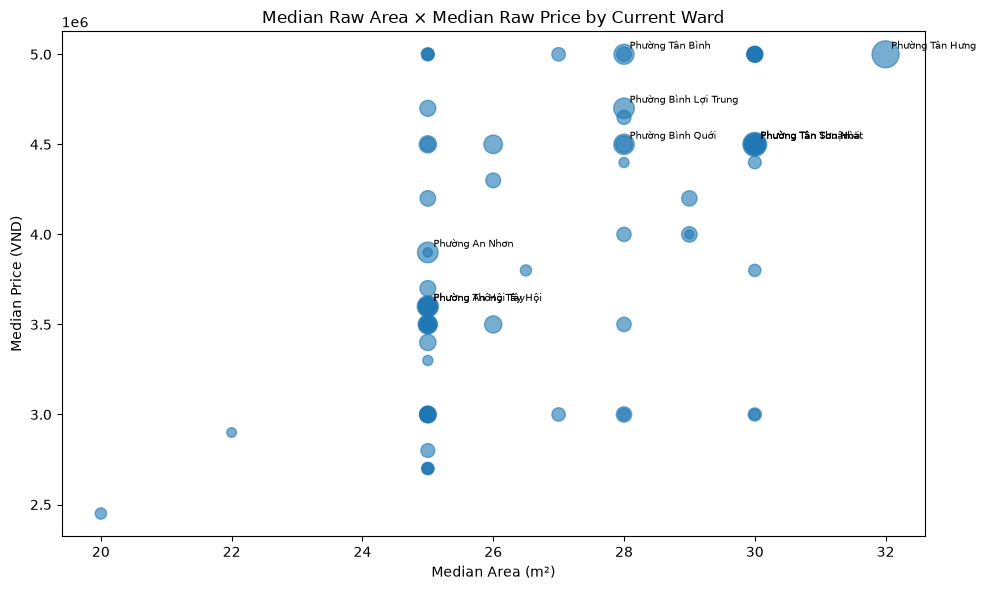

In [43]:
location_relationship = ward_base.groupby("ward_current").agg(Listings=("rental_post_id", "size"), **{"Valid Price Records": ("Price", "count"), "Valid Area Records": ("Area", "count"), "Median Price": ("Price", "median"), "Median Area": ("Area", "median"), "Median Price per Area": ("Price per Area", "median"), "Price Outlier (%)": ("Price Outlier", lambda x: x.mean() * 100), "Area Outlier (%)": ("Area Outlier", lambda x: x.mean() * 100)}).query("`Valid Price Records` >= @MIN_LOCATION_SAMPLE and `Valid Area Records` >= @MIN_LOCATION_SAMPLE").sort_values("Listings", ascending=False); display(location_relationship.reset_index(names="Current Ward").head(20))
plt.figure(figsize=(10, 6)); plt.scatter(location_relationship["Median Area"], location_relationship["Median Price"], s=np.sqrt(location_relationship["Listings"]) * 4, alpha=.6)
for ward, row in location_relationship.head(10).iterrows(): plt.annotate(ward, (row["Median Area"], row["Median Price"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
plt.title("Median Raw Area × Median Raw Price by Current Ward"); plt.xlabel("Median Area (m²)"); plt.ylabel("Median Price (VND)"); plt.tight_layout(); plt.show()

## 08.11 Relationship Findings

In [44]:
price_low_cut, price_high_cut = positive_pair["Price"].quantile([.01, .99]); area_low_cut, area_high_cut = positive_pair["Area"].quantile([.01, .99]); ratio_high_cut = positive_pair["Price per Area"].quantile(.999)
relationship_issue_masks = {"Large Area + Extremely Low Price": relationship_audit["Area"].ge(area_high_cut) & relationship_audit["Price"].le(price_low_cut), "Small Area + Extremely High Price": relationship_audit["Area"].le(area_low_cut) & relationship_audit["Price"].ge(price_high_cut), "Extreme Price per Area": relationship_audit["Price per Area"].ge(ratio_high_cut), "Resolved Ward + Price/Area Outlier": relationship_audit["ward_current"].notna() & (relationship_audit["Price Outlier"] | relationship_audit["Area Outlier"]), "Address Missing + Coordinate Available": ~address_available & has_coordinates, "Address Available + Ward Unresolved": address_available & relationship_audit["ward_current"].isna()}
relationship_issue_summary = pd.DataFrame({"Relationship Issue": list(relationship_issue_masks), "Affected Rows": [x.sum() for x in relationship_issue_masks.values()]}); relationship_issue_summary["Affected (%)"] = (relationship_issue_summary["Affected Rows"] / len(df) * 100).round(2); display(relationship_issue_summary)
display(Markdown(f"Observed in the current RoomBeacon raw dataset: Price × area Pearson correlation is **{relationship_correlation.loc[1, 'Value']:.3f}** and Spearman correlation is **{relationship_correlation.loc[2, 'Value']:.3f}**. Source composition must be considered before interpreting location patterns; correlation does not imply causation."))

,Relationship Issue,Affected Rows,Affected (%)
0,Large Area + Extremely Low Price,15,0.01
1,Small Area + Extremely High Price,19,0.01
2,Extreme Price per Area,130,0.10
3,Resolved Ward + Price/Area Outlier,7740,5.84
4,Address Missing + Coordinate Available,0,0.00
5,Address Available + Ward Unresolved,34902,26.35


Observed in the current RoomBeacon raw dataset: Price × area Pearson correlation is **0.011** and Spearman correlation is **0.304**. Source composition must be considered before interpreting location patterns; correlation does not imply causation.

# 09. RoomBeacon Data Readiness

> **Purpose:** Measure how far current RAW records can proceed into Processing. Derived states are temporary audit evidence; no source value is cleaned, replaced or written back.

## 09.1 Critical Field Readiness

Every stage is cumulative. A complete coordinate pair is only a candidate—not trusted spatial data.

,Readiness Stage,Listings,Percentage of Total (%)
0,All Listings,132436,100.00
1,Usable Title,131947,99.63
2,Usable Title + Price,127659,96.39
3,Usable Title + Price + Area,125564,94.81
4,Usable Title + Price + Area + Resolved Current...,83311,62.91
5,Usable Title + Price + Area + Resolved Current...,8293,6.26


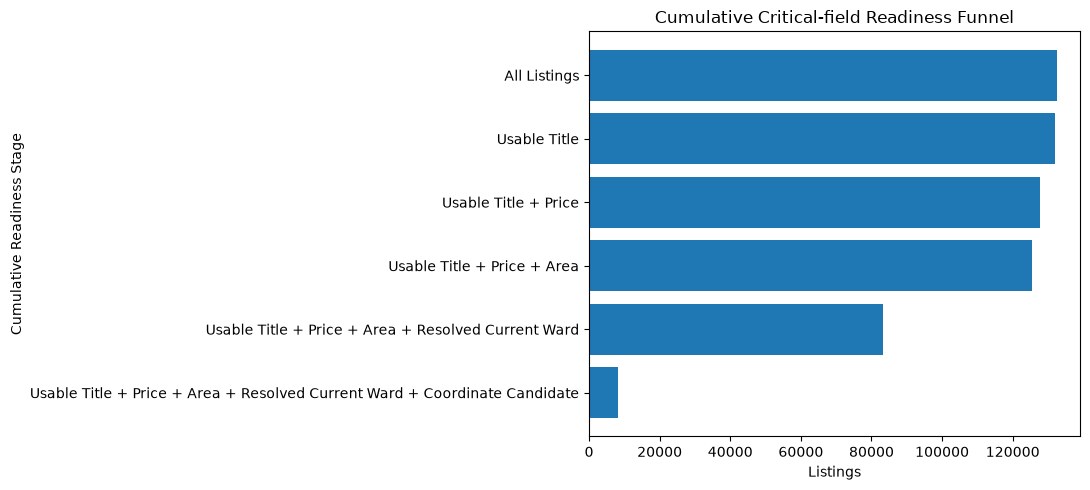

In [45]:
title_text = df["title_raw"].astype("string"); usable_title = title_text.notna() & title_text.str.strip().ne("")
usable_price = pd.to_numeric(df["price_amount"], errors="coerce").gt(0); usable_area = pd.to_numeric(df["area_value"], errors="coerce").gt(0); resolved_current_ward = location_audit["ward_current"].notna(); coordinate_candidate = has_coordinates
readiness_masks = {"All Listings": pd.Series(True, index=df.index), "Usable Title": usable_title, "Usable Title + Price": usable_title & usable_price, "Usable Title + Price + Area": usable_title & usable_price & usable_area, "Usable Title + Price + Area + Resolved Current Ward": usable_title & usable_price & usable_area & resolved_current_ward, "Usable Title + Price + Area + Resolved Current Ward + Coordinate Candidate": usable_title & usable_price & usable_area & resolved_current_ward & coordinate_candidate}
readiness_funnel = pd.DataFrame({"Readiness Stage": list(readiness_masks), "Listings": [x.sum() for x in readiness_masks.values()]}); readiness_funnel["Percentage of Total (%)"] = (readiness_funnel["Listings"] / len(df) * 100).round(2); display(readiness_funnel)
plt.figure(figsize=(11, 5)); plt.barh(readiness_funnel["Readiness Stage"].iloc[::-1], readiness_funnel["Listings"].iloc[::-1]); plt.title("Cumulative Critical-field Readiness Funnel"); plt.xlabel("Listings"); plt.ylabel("Cumulative Readiness Stage"); plt.tight_layout(); plt.show()

## 09.2 Rental Title Usability

This checks descriptive usability only. It does not infer or assign rental-property types.

,Title Status,Listings,Percentage (%)
0,Normal Descriptive Title,131186,99.06
1,Missing Title,489,0.37
2,Numeric-only Title,475,0.36
3,Room-code-like Title,259,0.2
4,Very Short Title,27,0.02


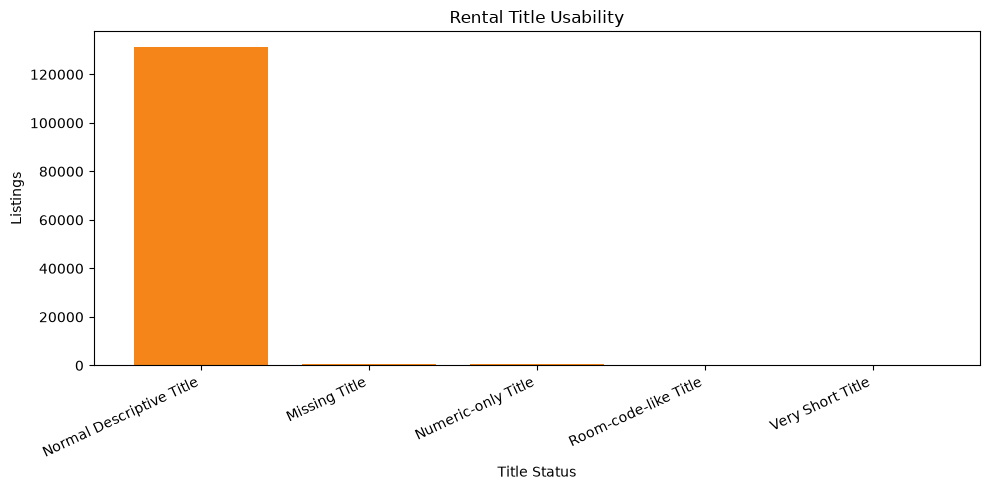

,source_code,source_listing_id,title_raw,Title Status
785,nhatrovn,6aa4de614c608e746fc53217,101,Numeric-only Title
788,nhatrovn,6aa3e2054c608e746fc50c44,103,Numeric-only Title
791,nhatrovn,6aa3dcb84c608e746fc50a89,101,Numeric-only Title
794,nhatrovn,6aa3d0184c608e746fc506ff,301,Numeric-only Title
797,nhatrovn,6aa3b5d24c608e746fc4fef6,102,Numeric-only Title
822,nhatrovn,6a9b98266e196447e64135b9,P.001,Room-code-like Title
831,nhatrovn,6a9a2a646e196447e640e45e,P.001,Room-code-like Title
832,nhatrovn,6a9a28c46e196447e640e3de,P.013,Room-code-like Title
834,nhatrovn,6a9929436e196447e640b7a4,L02,Room-code-like Title
838,nhatrovn,6a96809fd2bb9976e74272f9,A201,Room-code-like Title


In [46]:
stripped_title = title_text.str.strip(); title_length = stripped_title.str.len(); numeric_title = stripped_title.str.fullmatch(r"\d+", na=False); room_code_title = stripped_title.str.fullmatch(r"(?i)(?:p(?:hòng)?[.\s_-]*)?[a-z]?\d{1,4}[a-z]?", na=False) & ~numeric_title
title_status = pd.Series("Normal Descriptive Title", index=df.index, dtype="string"); title_status.loc[title_text.isna()] = "Missing Title"; title_status.loc[title_text.notna() & stripped_title.eq("")] = "Empty / Whitespace Title"; title_status.loc[title_length.between(1, 4, inclusive="both") & ~numeric_title & ~room_code_title] = "Very Short Title"; title_status.loc[numeric_title] = "Numeric-only Title"; title_status.loc[room_code_title] = "Room-code-like Title"
title_usability = title_status.value_counts().rename_axis("Title Status").reset_index(name="Listings"); title_usability["Percentage (%)"] = (title_usability["Listings"] / len(df) * 100).round(2); display(title_usability)
plt.figure(figsize=(10, 5)); plt.bar(title_usability["Title Status"], title_usability["Listings"], color="#F58518"); plt.title("Rental Title Usability"); plt.xlabel("Title Status"); plt.ylabel("Listings"); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
title_review_samples = df.assign(**{"Title Status": title_status}).loc[title_status.isin(["Numeric-only Title", "Room-code-like Title", "Very Short Title"]), ["source_code", "source_listing_id", "title_raw", "Title Status"]].groupby("Title Status", group_keys=False).head(5); display(title_review_samples)

## 09.3 Price & Area Usability

The latest-state view exposes numeric values but not original price/area text, so reparsing agreement cannot be measured here. Statistical outliers remain usable candidates but require Processing review.

In [47]:
price_numeric = pd.to_numeric(df["price_amount"], errors="coerce"); area_numeric = pd.to_numeric(df["area_value"], errors="coerce")
price_review = price_outlier_mask.fillna(False) | price_numeric.le(0).fillna(False); area_review = area_outlier_mask.fillna(False) | area_numeric.le(0).fillna(False)
price_area_usability = pd.DataFrame({"Field": ["Price", "Area"], "Available": [price_numeric.notna().sum(), area_numeric.notna().sum()], "Positive": [price_numeric.gt(0).sum(), area_numeric.gt(0).sum()], "Statistical Outlier": [price_outlier_mask.sum(), area_outlier_mask.sum()], "Suspicious Low": [price_numeric.lt(price_low_cut).sum(), area_numeric.lt(area_low_cut).sum()], "Suspicious High": [price_numeric.gt(price_high_cut).sum(), area_numeric.gt(area_high_cut).sum()], "Requires Review": [price_review.sum(), area_review.sum()], "Usable Candidate": [usable_price.sum(), usable_area.sum()]}); display(price_area_usability)
cross_field_status = pd.Series("Price + Area Available", index=df.index, dtype="string"); cross_field_status.loc[price_review & ~area_review] = "Price Suspicious + Area Normal"; cross_field_status.loc[~price_review & area_review] = "Area Suspicious + Price Normal"; cross_field_status.loc[price_review & area_review] = "Both Suspicious"; cross_field_status.loc[price_numeric.isna() | area_numeric.isna()] = "Price or Area Missing"; cross_field_status.loc[relationship_audit["Price per Area"].ge(ratio_high_cut)] = "Extreme Price/Area Ratio"
price_area_readiness = cross_field_status.value_counts().rename_axis("Cross-field Status").reset_index(name="Listings"); price_area_readiness["Percentage (%)"] = (price_area_readiness["Listings"] / len(df) * 100).round(2); display(price_area_readiness); display(relationship_audit.loc[cross_field_status.ne("Price + Area Available"), ["source_code", "source_listing_id", "title_raw", "Price", "Area", "Price per Area"]].head(12))

,Field,Available,Positive,Statistical Outlier,Suspicious Low,Suspicious High,Requires Review,Usable Candidate
0,Price,128148,128148,7476,1209,525,7476,128148
1,Area,130316,130316,5292,1035,1176,5292,130316


,Cross-field Status,Listings,Percentage (%)
0,Price + Area Available,114076,86.14
1,Price Suspicious + Area Normal,6814,5.15
2,Price or Area Missing,6387,4.82
3,Area Suspicious + Price Normal,4475,3.38
4,Both Suspicious,554,0.42
5,Extreme Price/Area Ratio,130,0.1


,source_code,source_listing_id,title_raw,Price,Area,Price per Area
28,mogi,22745032,Ktx phòng đẹp Phú Nhuận số lượng có hạn chỉ th...,1000000.0,80.0,12500.000000
30,mogi,22752502,Phú Nhuận Ký Túc Xá Tư Nhân Bao Trọn Chi Phí C...,1000000.0,120.0,8333.333333
32,mogi,22747403,"Quận 5, 10, Phú Nhuận Ký Túc Xá chỉ từ 1.000K",1000000.0,80.0,12500.000000
34,mogi,22748339,"Q.5, Q.10, Phú Nhuận ktx sinh viên chỉ từ 1.30...",1000000.0,120.0,8333.333333
35,mogi,22745062,KTX hiện đại - tiện nghi trọn gói chỉ từ 1.500...,1000000.0,80.0,12500.000000
37,mogi,22752506,Ký túc xá Phú Nhuận 1tr6 sạch – tự do - thoải mái,1000000.0,120.0,8333.333333
38,mogi,22745242,Ktx Hiện Đại - Cao Cấp - Thuận Tiện Trung Tâm ...,1000000.0,80.0,12500.000000
39,mogi,22752505,Ktx Cao Cấp Phú Nhuận Bao Trọn Chi Phí 1TR6,1000000.0,120.0,8333.333333
40,mogi,22752507,Chỉ từ 1.600.000 Giá Đã Bao Gồm Tất Cả Các Chi...,1000000.0,120.0,8333.333333
41,chothuenha,79960,"CHO THUÊ PHÒNG TRỌ - Khu vực nhà ở quân đội, a...",6500000.0,NaN,NaN


## 09.4 Location Resolution Readiness

The funnel reuses the existing temporary parser and post-merger mapping. It never overwrites `df`.

,Location Resolution Stage,Listings,Percentage of Total (%)
0,All Listings,132436,100.00
1,Address Available,123494,93.25
2,Address Parsed,115682,87.35
3,Ward Extracted,98525,74.39
4,Administrative Mapping Attempted,98525,74.39
5,Current Ward Resolved,88397,66.75
6,Coordinate Candidate Available,8309,6.27


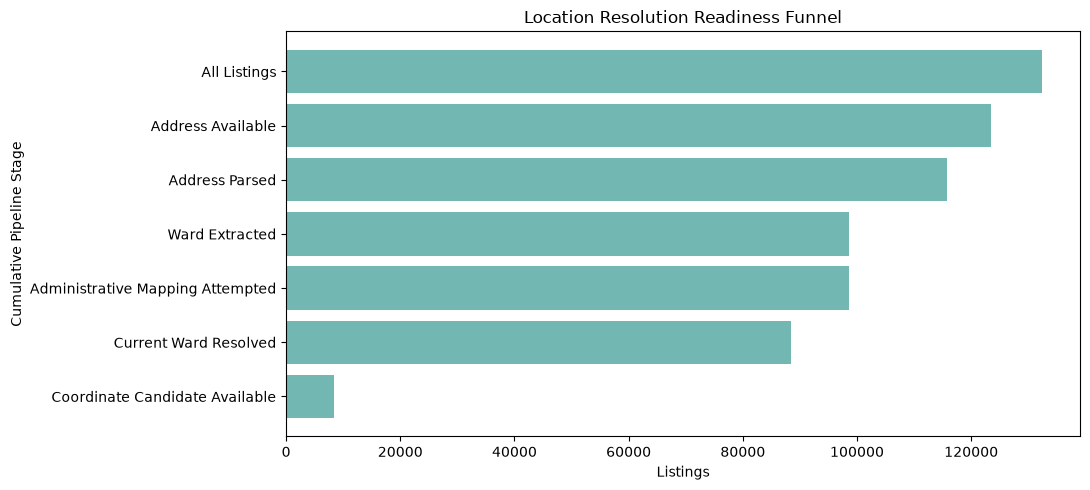

,Parse Status,Listings,Percentage (%)
0,PARSED,67835,51.22
1,PARTIALLY_PARSED,47847,36.13
2,NO_ADDRESS_EVIDENCE,8942,6.75
3,UNRECOGNIZED_FORMAT,7565,5.71
4,AMBIGUOUS,247,0.19


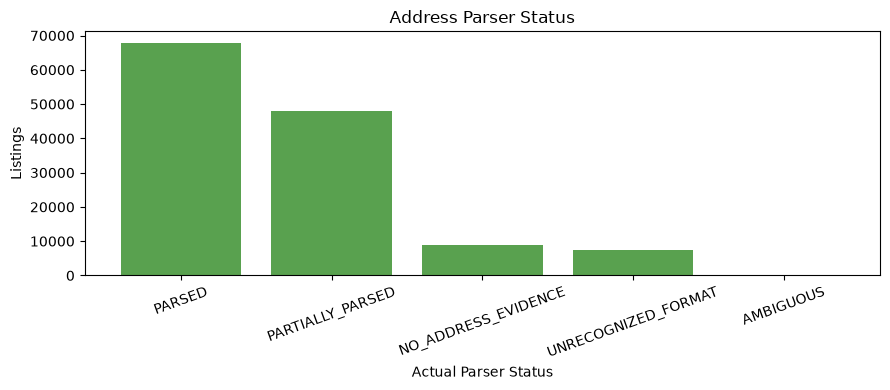

,best_address_text,street_text_extracted,ward_text_extracted,district_text_extracted,province_text_extracted,parse_status
0,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), ...",NaN,Phường 7 (Phường Võ Thị Sáu),Quận 3,TPHCM,PARSED
1,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",NaN,Phường 3,Quận 3,TPHCM,PARSED
2,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",NaN,Phường 2,Quận Bình Thạnh,TPHCM,PARSED
20,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí ...",NaN,Phường Chợ Lớn,Quận 5,NaN,PARTIALLY_PARSED
71,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh",NaN,Phường Tăng Nhơn Phú A,Thành phố Thủ Đức,NaN,PARTIALLY_PARSED
87,"306 Gò Dầu, P Tân Quý, Q Tân Phú - Gần Tân Quý...",NaN,NaN,Quận Tân Phú,NaN,PARTIALLY_PARSED
85,Trung Mỹ Tây TP. Hồ Chí Minh,NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT
92,"Nguyễn Tri Phương, , Vườn Lài TP. Hồ Chí Minh",NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT
112,"223, Bà Hạt, , Vườn Lài TP. Hồ Chí Minh",NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT
1005,"29/x Yên Thế, Phường 2, Tân Bình, TPHCM, Phườn...",NaN,Phường 2,Quận Tân Bình,TPHCM,AMBIGUOUS


,Administrative Status,Number of Records,Percentage of Total (%)
0,UNCHANGED,37033,27.96
1,MAPPED,51559,38.93
2,AMBIGUOUS,4923,3.72
3,UNMAPPED,5249,3.96
4,MISSING,33672,25.43


,best_address_text,ward_text_extracted,district_text_extracted,ward_normalized,ward_current,ward_mapping_status
0,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), ...",Phường 7 (Phường Võ Thị Sáu),Quận 3,Phường 7 (Phường Võ Thị Sáu),NaN,UNMAPPED
1,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",Phường 3,Quận 3,Phường 3,Phường Bàn Cờ,MAPPED
2,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",Phường 2,Quận Bình Thạnh,Phường 2,Phường Gia Định,MAPPED
3,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",Phường 15,Quận Tân Bình,Phường 15,NaN,AMBIGUOUS
4,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",Phường 15,Quận Tân Bình,Phường 15,NaN,AMBIGUOUS
6,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T...",Phường Tân Thới Nhất,Quận 12,Phường Tân Thới Nhất,Phường Đông Hưng Thuận,MAPPED
9,"Âu Cơ, Phường 10, Quận Tân Bình, TPHCM",Phường 10,Quận Tân Bình,Phường 10,Phường Bảy Hiền,MAPPED
29,"Thành Thái, Phường 14, Quận 10, TPHCM",Phường 14,Quận 10,Phường 14,NaN,AMBIGUOUS
31,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",Phường 6,Quận 5,Phường 6,NaN,UNMAPPED
32,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",Phường 6,Quận 5,Phường 6,NaN,UNMAPPED


In [48]:
parsed_address = location_audit["parse_status"].isin(["PARSED", "PARTIALLY_PARSED"]); ward_extracted = location_audit["ward_text_extracted"].notna(); mapping_attempted = location_audit["ward_mapping_status"].ne("MISSING")
location_resolution_masks = {"All Listings": pd.Series(True, index=df.index), "Address Available": address_available, "Address Parsed": address_available & parsed_address, "Ward Extracted": address_available & parsed_address & ward_extracted, "Administrative Mapping Attempted": address_available & parsed_address & ward_extracted & mapping_attempted, "Current Ward Resolved": address_available & parsed_address & resolved_current_ward, "Coordinate Candidate Available": address_available & parsed_address & resolved_current_ward & coordinate_candidate}
location_resolution_funnel = pd.DataFrame({"Location Resolution Stage": list(location_resolution_masks), "Listings": [x.sum() for x in location_resolution_masks.values()]}); location_resolution_funnel["Percentage of Total (%)"] = (location_resolution_funnel["Listings"] / len(df) * 100).round(2); display(location_resolution_funnel)
plt.figure(figsize=(11, 5)); plt.barh(location_resolution_funnel["Location Resolution Stage"].iloc[::-1], location_resolution_funnel["Listings"].iloc[::-1], color="#72B7B2"); plt.title("Location Resolution Readiness Funnel"); plt.xlabel("Listings"); plt.ylabel("Cumulative Pipeline Stage"); plt.tight_layout(); plt.show()
parser_status = location_audit["parse_status"].fillna("MISSING").value_counts().rename_axis("Parse Status").reset_index(name="Listings"); parser_status["Percentage (%)"] = (parser_status["Listings"] / len(df) * 100).round(2); display(parser_status)
plt.figure(figsize=(9, 4)); plt.bar(parser_status["Parse Status"], parser_status["Listings"], color="#59A14F"); plt.title("Address Parser Status"); plt.xlabel("Actual Parser Status"); plt.ylabel("Listings"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
parser_examples = pd.concat([location_audit[location_audit["parse_status"].eq(x)].head(3) for x in location_audit["parse_status"].dropna().unique()])[["best_address_text", "street_text_extracted", "ward_text_extracted", "district_text_extracted", "province_text_extracted", "parse_status"]]; display(parser_examples); display(administrative_status)
mapping_examples = location_audit[location_audit["ward_mapping_status"].isin(["MAPPED", "AMBIGUOUS", "UNMAPPED"])][["best_address_text", "ward_text_extracted", "district_text_extracted", "ward_normalized", "ward_current", "ward_mapping_status"]].groupby("ward_mapping_status", group_keys=False).head(4); display(mapping_examples)

## 09.5 Coordinate Trust Readiness

Availability does not imply radius-search readiness. States below are conservative EDA-only flags, not valid/invalid GPS labels.

,Coordinate Audit State,Listings,Percentage (%)
0,NO_COORDINATE,119587,90.3
1,HEAVILY_SHARED_COORDINATE,5834,4.41
2,REPEATED_MULTIPLE_ADDRESSES,4228,3.19
3,UNIQUE_COORDINATE,1470,1.11
4,REPEATED_SAME_LOCATION,807,0.61
5,REPEATED_MULTIPLE_WARDS,510,0.39


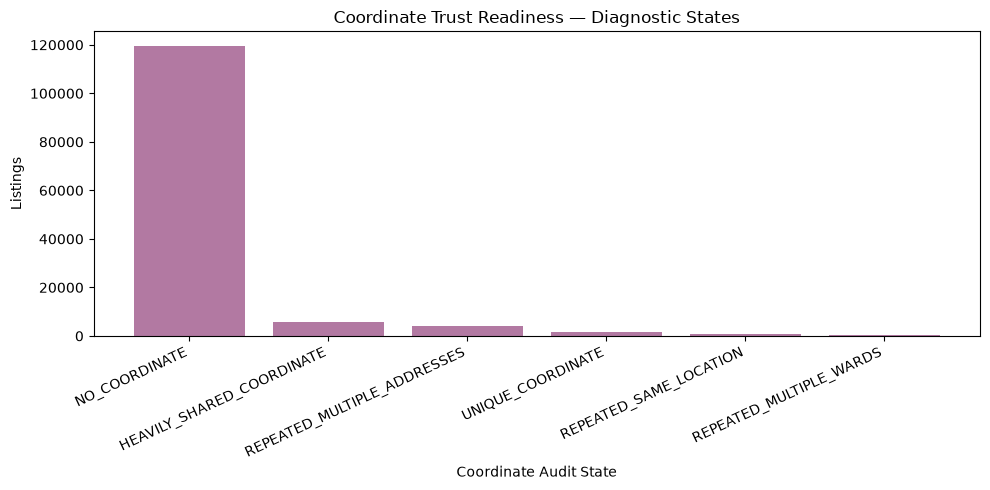

,Metric,Value
0,Coordinate Records,12849
1,Unique Coordinate Pairs,2141
2,Repeated Coordinate Records,11379
3,Largest Coordinate Group,285
4,Helper Trust Candidates,2277


,Latitude,Longitude,Listings,Distinct Addresses,Distinct Current Wards,Distinct Sources
1308,10.803558,106.641949,285,47,3,2
1386,10.806117,106.719341,236,33,3,2
1568,10.814095,106.621773,222,51,1,2
1649,10.819196,106.653244,190,48,0,2
1101,10.794777,106.621914,185,53,2,2
677,10.772981,106.661602,180,19,1,2
545,10.766117,106.617161,175,21,2,2
1759,10.829873,106.692741,171,27,2,2
1077,10.793849,106.641304,168,35,2,1
1420,10.807054,106.667713,166,42,2,2


In [49]:
coordinate_audit = df[["rental_post_id", "source_code", "best_address_text", "map_provider", "map_latitude", "map_longitude"]].copy().join(location_audit[["ward_current"]]); coordinate_audit = audit_coordinate_trust(coordinate_audit, address_col="best_address_text")
coordinate_key = coordinate_audit[["map_latitude", "map_longitude"]].round(6); coordinate_audit = coordinate_audit.assign(lat_key=coordinate_key["map_latitude"], lon_key=coordinate_key["map_longitude"])
coordinate_group_stats = coordinate_audit[coordinate_audit["coordinate_pair_valid"]].groupby(["lat_key", "lon_key"]).agg(Listings=("rental_post_id", "size"), **{"Distinct Addresses": ("best_address_text", "nunique"), "Distinct Current Wards": ("ward_current", "nunique"), "Distinct Sources": ("source_code", "nunique")}).reset_index()
coordinate_audit = coordinate_audit.merge(coordinate_group_stats, on=["lat_key", "lon_key"], how="left"); valid_coordinate = coordinate_audit["coordinate_pair_valid"]
coordinate_trust_state = pd.Series("NO_COORDINATE", index=coordinate_audit.index, dtype="string"); coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Listings"].eq(1)] = "UNIQUE_COORDINATE"; coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Listings"].gt(1)] = "REPEATED_SAME_LOCATION"; coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Distinct Addresses"].gt(1)] = "REPEATED_MULTIPLE_ADDRESSES"; coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Distinct Current Wards"].gt(1)] = "REPEATED_MULTIPLE_WARDS"; coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Listings"].ge(50)] = "HEAVILY_SHARED_COORDINATE"; coordinate_audit["coordinate_trust_state"] = coordinate_trust_state
coordinate_trust_summary = coordinate_trust_state.value_counts().rename_axis("Coordinate Audit State").reset_index(name="Listings"); coordinate_trust_summary["Percentage (%)"] = (coordinate_trust_summary["Listings"] / len(df) * 100).round(2); display(coordinate_trust_summary)
plt.figure(figsize=(10, 5)); plt.bar(coordinate_trust_summary["Coordinate Audit State"], coordinate_trust_summary["Listings"], color="#B279A2"); plt.title("Coordinate Trust Readiness — Diagnostic States"); plt.xlabel("Coordinate Audit State"); plt.ylabel("Listings"); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
coordinate_summary = pd.DataFrame({"Metric": ["Coordinate Records", "Unique Coordinate Pairs", "Repeated Coordinate Records", "Largest Coordinate Group", "Helper Trust Candidates"], "Value": [valid_coordinate.sum(), len(coordinate_group_stats), coordinate_group_stats.loc[coordinate_group_stats["Listings"].gt(1), "Listings"].sum(), coordinate_group_stats["Listings"].max(), coordinate_audit["has_trusted_coordinate"].sum()]}); display(coordinate_summary); display(coordinate_group_stats.sort_values(["Listings", "Distinct Current Wards", "Distinct Addresses"], ascending=False).head(15).rename(columns={"lat_key": "Latitude", "lon_key": "Longitude"}))

## 09.6 Source-specific Readiness

Percentages describe crawler readiness, not market activity.

,Data Source,Title Usable (%),Price Usable (%),Area Usable (%),Address Available (%),Ward Parsed (%),Current Ward Resolved (%),Coordinate Available (%),Coordinate Requires Review (%),Price Requires Review (%)
0,cafeland,100.0,99.9,100.0,100.0,34.1,34.0,30.7,88.6,6.5
1,chothuenha,100.0,100.0,0.0,100.0,98.8,86.9,0.0,100.0,6.0
2,chothuephongtro,100.0,88.7,100.0,100.0,90.1,73.9,0.0,100.0,17.3
3,mogi,100.0,100.0,100.0,100.0,97.7,75.6,99.3,88.8,1.0
4,muaban,100.0,99.9,0.0,100.0,99.3,80.4,0.0,100.0,1.7
5,nhatot,81.5,99.9,99.8,100.0,86.9,68.2,0.0,100.0,1.1
6,nhatrovn,100.0,100.0,89.0,100.0,99.2,66.2,0.0,100.0,0.8
7,phongtro123,100.0,99.7,99.9,87.5,67.9,66.5,0.0,100.0,0.7
8,tromoi,100.0,95.7,0.0,100.0,74.5,60.4,25.9,82.4,2.0


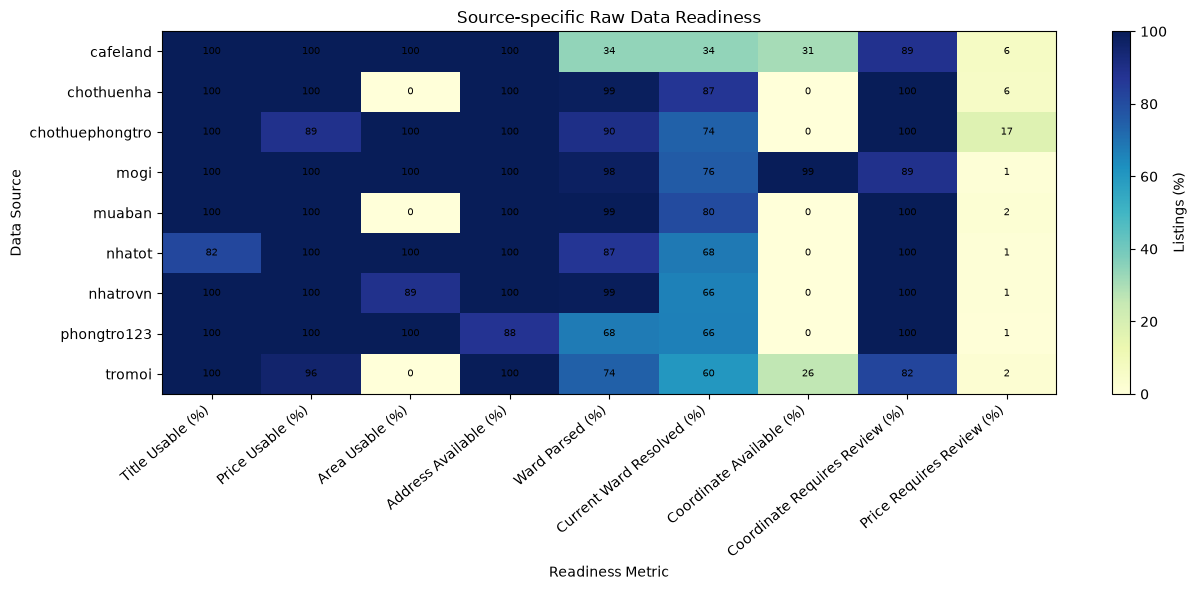

In [50]:
source_readiness_flags = pd.DataFrame({"source_code": df["source_code"], "Title Usable (%)": usable_title, "Price Usable (%)": usable_price, "Area Usable (%)": usable_area, "Address Available (%)": address_available, "Ward Parsed (%)": ward_extracted, "Current Ward Resolved (%)": resolved_current_ward, "Coordinate Available (%)": coordinate_candidate, "Coordinate Requires Review (%)": ~coordinate_audit["coordinate_trust_state"].isin(["UNIQUE_COORDINATE", "REPEATED_SAME_LOCATION"]), "Price Requires Review (%)": price_review})
source_readiness = source_readiness_flags.groupby("source_code").mean().mul(100).round(1); display(source_readiness.reset_index(names="Data Source"))
source_readiness_values = source_readiness.to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(13, 6)); image = ax.imshow(source_readiness_values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100); plt.colorbar(image, ax=ax, label="Listings (%)"); ax.set_xticks(range(len(source_readiness.columns)), source_readiness.columns, rotation=40, ha="right"); ax.set_yticks(range(len(source_readiness)), source_readiness.index)
for r in range(len(source_readiness)):
    for c in range(len(source_readiness.columns)): ax.text(c, r, f"{source_readiness_values[r, c]:.0f}", ha="center", va="center", fontsize=7)
ax.set(title="Source-specific Raw Data Readiness", xlabel="Readiness Metric", ylabel="Data Source"); plt.tight_layout(); plt.show()

## 09.7 Duplicate / Repost Evidence

Candidates require non-missing normalized address, positive price and positive area. Shared coordinates alone are never evidence. No rows are merged or deleted.

In [51]:
duplicate_audit = relationship_audit[["rental_post_id", "source_code", "source_listing_id", "title_raw", "Price", "Area", "best_address_text", "ward_current"]].copy(); duplicate_audit["address_key"] = duplicate_audit["best_address_text"].astype("string").str.normalize("NFKC").str.lower().str.replace(r"\s+", " ", regex=True).str.strip().replace("", pd.NA)
candidate_mask = duplicate_audit["address_key"].notna() & duplicate_audit["Price"].gt(0) & duplicate_audit["Area"].gt(0)
candidate_groups = duplicate_audit[candidate_mask].groupby(["address_key", "Price", "Area"], dropna=False).filter(lambda x: len(x) > 1).copy(); candidate_groups["Candidate Group"] = candidate_groups.groupby(["address_key", "Price", "Area"], sort=False).ngroup().add(1)
group_scope = candidate_groups.groupby("Candidate Group")["source_code"].nunique().gt(1).map({True: "CROSS_SOURCE", False: "SAME_SOURCE"}); candidate_groups["Duplicate Candidate Scope"] = candidate_groups["Candidate Group"].map(group_scope); candidate_groups["Match Reason"] = "Same normalized address + raw price + raw area"
duplicate_candidate_summary = candidate_groups.groupby("Duplicate Candidate Scope").agg(**{"Candidate Groups": ("Candidate Group", "nunique"), "Candidate Listings": ("rental_post_id", "size")}).reindex(["SAME_SOURCE", "CROSS_SOURCE"], fill_value=0).reset_index(); display(duplicate_candidate_summary)
duplicate_candidate_samples = candidate_groups.sort_values(["Candidate Group", "source_code"])[["Candidate Group", "source_code", "source_listing_id", "title_raw", "Price", "Area", "best_address_text", "ward_current", "Match Reason"]].head(20); display(duplicate_candidate_samples)

,Duplicate Candidate Scope,Candidate Groups,Candidate Listings
0,SAME_SOURCE,11463,36479
1,CROSS_SOURCE,15,49


,Candidate Group,source_code,source_listing_id,title_raw,Price,Area,best_address_text,ward_current,Match Reason
4,1,mogi,21964621,🏡 PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - ...,3000000.0,30.0,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",NaN,Same normalized address + raw price + raw area
158,1,mogi,21966483,💥 Phòng cửa sổ thoáng Trường Chinh gần BigC NEW!!,3000000.0,30.0,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",NaN,Same normalized address + raw price + raw area
5,2,mogi,21948330,🏡Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Cô...,3000000.0,35.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",Phường Trung Mỹ Tây,Same normalized address + raw price + raw area
4966,2,mogi,22748859,⭐ PHÒNG TRỌ GIÁ RẺ - FULL Nội Thất - Ngay phần...,3000000.0,35.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",Phường Trung Mỹ Tây,Same normalized address + raw price + raw area
4973,2,mogi,22748846,⭐ PHÒNG TRỌ GIÁ RẺ - FULL NỘI THẤT - Ngay phần...,3000000.0,35.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",Phường Trung Mỹ Tây,Same normalized address + raw price + raw area
...,...,...,...,...,...,...,...,...,...
10849,4,mogi,22117638,Căn Hộ Mới Xây - Full Nội Thất - Ban Công Riên...,4000000.0,30.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",Phường Trung Mỹ Tây,Same normalized address + raw price + raw area
36358,4,mogi,21998168,"Căn Hộ Giá Rẻ, Full Nội Thất, Ban Công Ngay Tô...",4000000.0,30.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM",Phường Trung Mỹ Tây,Same normalized address + raw price + raw area
10,5,mogi,21911590,🏡 PHÒNG CAO CẤP GIÁ RẺ - Full Nội Thất Mới - N...,4000000.0,30.0,"Lê Đức Thọ, Phường 6, Quận Gò Vấp, TPHCM",Phường An Nhơn,Same normalized address + raw price + raw area
3859,5,mogi,22743265,Phòng Tách Bếp Thoáng Ngay Công Viên Văn Hóa G...,4000000.0,30.0,"Lê Đức Thọ, Phường 6, Quận Gò Vấp, TPHCM",Phường An Nhơn,Same normalized address + raw price + raw area


## 09.8 Overall Readiness Summary

In [52]:
overall_readiness = pd.DataFrame([
["Identifier Integrity", "HEALTHY" if df["rental_post_id"].is_unique else "REQUIRES INVESTIGATION", f"{df['rental_post_id'].nunique():,} unique IDs / {len(df):,} rows", "None observed" if df["rental_post_id"].is_unique else "Duplicate identifiers"],
["Missing Data", "PARTIAL", f"{readiness_funnel.iloc[-2]['Listings']:,} reach the resolved-ward stage", "Critical fields are not jointly complete"],
["Title Usability", "PARTIAL", f"{usable_title.sum():,} non-empty titles", "Short/code-like titles need review"],
["Price Usability", "REQUIRES PROCESSING", f"{usable_price.sum():,} positive; {price_review.sum():,} review flags", "Raw text unavailable for reparse comparison"],
["Area Usability", "REQUIRES PROCESSING", f"{usable_area.sum():,} positive; {area_review.sum():,} review flags", "Unit and extreme-value validation"],
["Address Parsing", "PARTIAL", f"{parsed_address.sum():,} parsed/partially parsed", "Unrecognized and missing addresses"],
["Administrative Mapping", "PARTIAL", f"{resolved_current_ward.sum():,} current wards resolved", "Ambiguous/unmapped records"],
["Coordinate Readiness", "REQUIRES INVESTIGATION", f"{coordinate_candidate.sum():,} complete pairs; {coordinate_audit['has_trusted_coordinate'].sum():,} helper trust candidates", "Shared points and limited coverage"],
["Source Consistency", "REQUIRES PROCESSING", f"{len(source_readiness):,} sources compared", "Readiness varies by crawler source"],
["Duplicate Risk", "REQUIRES INVESTIGATION", f"{candidate_groups['Candidate Group'].nunique():,} conservative candidate groups", "Entity-resolution review"],
], columns=["Readiness Area", "Status", "Evidence", "Main Blocker"]); display(overall_readiness)

,Readiness Area,Status,Evidence,Main Blocker
0,Identifier Integrity,HEALTHY,"132,436 unique IDs / 132,436 rows",None observed
1,Missing Data,PARTIAL,"83,311 reach the resolved-ward stage",Critical fields are not jointly complete
2,Title Usability,PARTIAL,"131,947 non-empty titles",Short/code-like titles need review
3,Price Usability,REQUIRES PROCESSING,"128,148 positive; 7,476 review flags",Raw text unavailable for reparse comparison
4,Area Usability,REQUIRES PROCESSING,"130,316 positive; 5,292 review flags",Unit and extreme-value validation
5,Address Parsing,PARTIAL,"115,682 parsed/partially parsed",Unrecognized and missing addresses
6,Administrative Mapping,PARTIAL,"88,592 current wards resolved",Ambiguous/unmapped records
7,Coordinate Readiness,REQUIRES INVESTIGATION,"12,849 complete pairs; 2,277 helper trust cand...",Shared points and limited coverage
8,Source Consistency,REQUIRES PROCESSING,9 sources compared,Readiness varies by crawler source
9,Duplicate Risk,REQUIRES INVESTIGATION,"11,478 conservative candidate groups",Entity-resolution review


# 10. Data Quality Findings

Runtime findings describe the RAW snapshot only, not true rental-market supply, price levels or ward rankings.

In [53]:
display(Markdown(f"""
### Healthy / Reliable
- Listing identifiers are unique across **{len(df):,}** latest-state records; no negative price, area or active-day values were detected.

### Missing Data Problems
- Missing candidates: **{price_numeric.isna().sum():,}** prices, **{area_numeric.isna().sum():,}** areas and **{(~address_available).sum():,}** best addresses.

### Price / Area Problems
- Existing IQR diagnostics flag **{price_outlier_mask.sum():,}** prices and **{area_outlier_mask.sum():,}** areas; flags are review evidence, not automatic invalidation.

### Text Problems
- **{title_status.isin(['Numeric-only Title', 'Room-code-like Title', 'Very Short Title']).sum():,}** titles are short, numeric or room-code-like.

### Address / Mapping Problems
- **{location_audit['parse_status'].isin(['UNRECOGNIZED_FORMAT', 'MISSING']).sum():,}** records fail parser usability and **{location_audit['ward_mapping_status'].isin(['AMBIGUOUS', 'UNMAPPED']).sum():,}** remain ambiguous or unmapped.

### Coordinate Problems
- Only **{coordinate_candidate.sum():,}** records contain complete pairs; heavily shared or conflicting coordinates require validation before radius search.

### Source-specific Problems
- Field readiness and raw price/area distributions vary by crawler source; source composition must be considered before location interpretation.

### Duplicate / Repost Risk
- Conservative address + price + area matching identifies **{candidate_groups['Candidate Group'].nunique():,}** possible duplicate/repost groups; none are confirmed or removed.

### Cross-variable Findings
- Raw price × area correlation is Pearson **{relationship_correlation.loc[1, 'Value']:.3f}** and Spearman **{relationship_correlation.loc[2, 'Value']:.3f}**. Ward summaries expose sample size and ward × source tables expose representation effects.

### Requires Investigation
- Parser edge cases, numeric unit semantics, shared-coordinate meaning, chronology exceptions and duplicate candidates need human or Processing-stage validation.
"""))


### Healthy / Reliable
- Listing identifiers are unique across **132,436** latest-state records; no negative price, area or active-day values were detected.

### Missing Data Problems
- Missing candidates: **4,288** prices, **2,120** areas and **8,942** best addresses.

### Price / Area Problems
- Existing IQR diagnostics flag **7,476** prices and **5,292** areas; flags are review evidence, not automatic invalidation.

### Text Problems
- **761** titles are short, numeric or room-code-like.

### Address / Mapping Problems
- **7,565** records fail parser usability and **10,172** remain ambiguous or unmapped.

### Coordinate Problems
- Only **12,849** records contain complete pairs; heavily shared or conflicting coordinates require validation before radius search.

### Source-specific Problems
- Field readiness and raw price/area distributions vary by crawler source; source composition must be considered before location interpretation.

### Duplicate / Repost Risk
- Conservative address + price + area matching identifies **11,478** possible duplicate/repost groups; none are confirmed or removed.

### Cross-variable Findings
- Raw price × area correlation is Pearson **0.011** and Spearman **0.304**. Ward summaries expose sample size and ward × source tables expose representation effects.

### Requires Investigation
- Parser edge cases, numeric unit semantics, shared-coordinate meaning, chronology exceptions and duplicate candidates need human or Processing-stage validation.


# 11. Cleaning & Processing Requirements

The RAW EDA stops here. These requirements describe the next Processing stage; they are not implemented in this notebook.

In [54]:
processing_requirements = pd.DataFrame([
["Non-descriptive or inconsistent titles", f"{title_status.ne('Normal Descriptive Title').sum():,} titles need review", "Standardize text and perform validated semantic extraction", "Searchable titles and explicit canonical attributes"],
["Price values missing or flagged", f"{price_numeric.isna().sum():,} missing; {price_review.sum():,} review flags", "Expose raw price text, reparse by source and validate units", "Traceable accepted price candidate or review status"],
["Area values missing or flagged", f"{area_numeric.isna().sum():,} missing; {area_review.sum():,} review flags", "Expose raw area text, reparse and validate units/extremes", "Traceable accepted area candidate or review status"],
["Cross-field price/area anomalies", f"{relationship_issue_summary['Affected Rows'].sum():,} non-exclusive flags", "Add cross-field validation without deleting outliers", "Reviewable anomaly reasons"],
["Address parser gaps", f"{location_audit['parse_status'].isin(['UNRECOGNIZED_FORMAT', 'MISSING']).sum():,} parser failures", "Improve parser and source-specific contamination handling", "Structured location evidence with provenance"],
["Administrative mapping unresolved", f"{location_audit['ward_mapping_status'].isin(['AMBIGUOUS', 'UNMAPPED']).sum():,} ambiguous/unmapped", "Strengthen legacy mapping and explicit unresolved handling", "Canonical current ward or documented unresolved state"],
["Coordinate availability is not trust", f"{coordinate_candidate.sum():,} complete pairs; shared groups observed", "Classify provider, precision, shared-point and address consistency", "Coordinate trust status before spatial search"],
["Source-specific readiness differences", f"{len(source_readiness):,} crawler sources audited", "Apply source-specific parsing and normalization rules", "Comparable fields with preserved source provenance"],
["Possible duplicates/reposts", f"{candidate_groups['Candidate Group'].nunique():,} conservative candidate groups", "Develop auditable entity resolution using multiple signals", "Candidate links without premature row deletion"],
["Temporal semantics need confirmation", f"{(df['first_observed_at'] > df['last_observed_at']).sum():,} chronology exceptions", "Verify observation/backfill semantics", "Documented and testable lifecycle fields"],
], columns=["Observed Problem", "Evidence", "Required Processing", "Expected Result"]); display(processing_requirements)

,Observed Problem,Evidence,Required Processing,Expected Result
0,Non-descriptive or inconsistent titles,"1,250 titles need review",Standardize text and perform validated semanti...,Searchable titles and explicit canonical attri...
1,Price values missing or flagged,"4,288 missing; 7,476 review flags","Expose raw price text, reparse by source and v...",Traceable accepted price candidate or review s...
2,Area values missing or flagged,"2,120 missing; 5,292 review flags","Expose raw area text, reparse and validate uni...",Traceable accepted area candidate or review st...
3,Cross-field price/area anomalies,"42,806 non-exclusive flags",Add cross-field validation without deleting ou...,Reviewable anomaly reasons
4,Address parser gaps,"7,565 parser failures",Improve parser and source-specific contaminati...,Structured location evidence with provenance
5,Administrative mapping unresolved,"10,172 ambiguous/unmapped",Strengthen legacy mapping and explicit unresol...,Canonical current ward or documented unresolve...
6,Coordinate availability is not trust,"12,849 complete pairs; shared groups observed","Classify provider, precision, shared-point and...",Coordinate trust status before spatial search
7,Source-specific readiness differences,9 crawler sources audited,Apply source-specific parsing and normalizatio...,Comparable fields with preserved source proven...
8,Possible duplicates/reposts,"11,478 conservative candidate groups",Develop auditable entity resolution using mult...,Candidate links without premature row deletion
9,Temporal semantics need confirmation,5 chronology exceptions,Verify observation/backfill semantics,Documented and testable lifecycle fields
